# COE Price Model & Quota Elasticity


predict COE prices for Cat A & B. work out how much price moves if quota changes.

**what we found:**
1. Quota does affect price. but a plain regression hides it (R² only 10-25%, cos quota and price
   both move in multi year cycles). control for the year, R² jumps to ~94%. **10% more quota →
   price falls ~3.1% (A) / ~4.4% (B).** B moves more than A.
2. Both numbers small (well under 1). thats why May-2023's quota top-up only bought **3-4%** price
   relief, not the full 24%.
3. short term forecasting - simple wins. last round's price / PQP beats machine learning. COE price
   basically moves like a random walk.
4. turned the elasticity into a table. give us a quota change, get the price impact back.

**bottom line:** quota moves price but its a blunt tool. need a big sustained supply increase to
actually move price. B needs a smaller nudge than A tho for the same effect.


In [201]:
import warnings
warnings.filterwarnings("ignore")

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 140)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# house style, roughly matches LTA's chart template
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Segoe UI", "Helvetica", "Arial", "DejaVu Sans"],
    "figure.facecolor": "#fcfcfb",
    "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": "#c3c2b7",
    "axes.labelcolor": "#52514e",
    "text.color": "#0b0b0b",
    "xtick.color": "#898781",
    "ytick.color": "#898781",
    "axes.grid": True,
    "grid.color": "#e1e0d9",
    "grid.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.titlelocation": "left",
    "axes.titlecolor": "#0b0b0b",
    "figure.dpi": 110,
    "savefig.dpi": 110,
})

# colors are fixed, never remapped. A & B get full strength since theyre the focus,
# C/D/E just for context so lower alpha
CAT_COLOR = {
    "Category A": "#2a78d6",   # blue   (slot 1)
    "Category B": "#008300",   # green  (slot 2)
    "Category C": "#e87ba4",   # magenta(slot 3) - context only
    "Category D": "#eda100",   # yellow (slot 4) - context only
    "Category E": "#1baf7a",   # aqua   (slot 5) - context only
}
FOCUS_CATS = ["Category A", "Category B"]
CAT_ORDER = ["Category A", "Category B", "Category C", "Category D", "Category E"]
CONTEXT_ALPHA = 0.55
INK = "#0b0b0b"
INK_SECONDARY = "#52514e"
INK_MUTED = "#898781"
GRID = "#e1e0d9"
GOOD = "#0ca30c"       # price relief / favourable
CRITICAL = "#d03b3b"   # record-high / adverse
DIVERGE_UP, DIVERGE_DOWN = "#e34948", "#2a78d6"

def style_ax(ax, ygrid_only=True):
    if ygrid_only:
        ax.grid(axis="x", visible=False)
    ax.tick_params(length=0)
    return ax

def sgd(ax_axis):
    ax_axis.set_major_formatter(mticker.FuncFormatter(lambda x, _: "${:,.0f}".format(x)))

def find_data_dir(start: Path) -> Path:
    '''Find the 'data' folder, checking here and up two levels, so it works no matter
    where the notebook is run from.'''
    for candidate in (start / "data", start.parent / "data", start.parent.parent / "data"):
        if (candidate / "COEBiddingResultsPrices.csv").exists():
            return candidate
    raise FileNotFoundError("Can't find the data folder. Make sure the 3 source CSVs are nearby.")


BASE = Path.cwd()
DATA_DIR = find_data_dir(BASE)
OUT_DATA = BASE / "output" / "data"
OUT_CHARTS = BASE / "output" / "charts"
OUT_DATA.mkdir(parents=True, exist_ok=True)
OUT_CHARTS.mkdir(parents=True, exist_ok=True)


## 3. Data Loading & Cleaning


In [202]:
long_raw = pd.read_csv(DATA_DIR / "COEBiddingResultsPrices.csv")
print(f"Shape: {long_raw.shape}")
print(long_raw.dtypes)
long_raw.head()


Shape: (1955, 7)
month              str
bidding_no       int64
vehicle_class      str
quota            int64
bids_success       str
bids_received      str
premium          int64
dtype: object


,month,bidding_no,vehicle_class,quota,bids_success,bids_received,premium
0,2010-01,1,Category A,1152,1145,1342,18502
1,2010-01,1,Category B,687,679,883,19190
2,2010-01,1,Category C,173,173,265,19001
3,2010-01,1,Category D,373,365,509,889
4,2010-01,1,Category E,586,567,1011,19889


bug: `bids_success`/`bids_received` loaded as text not numbers. source writes `"1,007"` with a
comma once it crosses 1000. fix below w/ `thousands=","`.


In [203]:
# double check then fix by re-reading with thousands=","
sample_bad = long_raw.loc[pd.to_numeric(long_raw["bids_success"], errors="coerce").isna(), "bids_success"].unique()[:5]
print("Non-numeric-looking bids_success values, e.g.:", sample_bad)

long_df = pd.read_csv(DATA_DIR / "COEBiddingResultsPrices.csv", thousands=",")
long_df["month_dt"] = pd.to_datetime(long_df["month"], format="%Y-%m")
long_df = long_df.sort_values(["vehicle_class", "month_dt", "bidding_no"]).reset_index(drop=True)
assert long_df[["quota", "bids_success", "bids_received", "premium"]].dtypes.eq(np.int64).all()
print("\nClean dtypes:")
print(long_df.dtypes)
print(f"\n{len(long_df):,} rows | {long_df.vehicle_class.nunique()} vehicle classes | "
      f"{long_df.month_dt.min():%b-%Y} to {long_df.month_dt.max():%b-%Y}")


Non-numeric-looking bids_success values, e.g.: <ArrowStringArray>
['1,007', '1,048', '1,035', '1,038', '1,034']
Length: 5, dtype: str

Clean dtypes:
month                       str
bidding_no                int64
vehicle_class               str
quota                     int64
bids_success              int64
bids_received             int64
premium                   int64
month_dt         datetime64[us]
dtype: object

1,955 rows | 5 vehicle classes | Jan-2010 to Jul-2026


In [204]:
# missing rounds? shld be exactly 2 per cat per month unless bidding was paused
rounds_per_month = long_df.groupby(["month", "vehicle_class"]).size().reset_index(name="n_rounds")
print("Round counts other than 2:")
print(rounds_per_month[rounds_per_month.n_rounds != 2].vehicle_class.value_counts())
print()
print(rounds_per_month[rounds_per_month.n_rounds != 2].sort_values("month"))

all_months = pd.period_range(long_df.month_dt.min(), long_df.month_dt.max(), freq="M")
have_months = set(long_df.month_dt.dt.to_period("M"))
print("\nCalendar months with ZERO bidding activity at all:", [m for m in all_months if m not in have_months])


Round counts other than 2:
vehicle_class
Category A    1
Category B    1
Category C    1
Category D    1
Category E    1
Name: count, dtype: int64

       month vehicle_class  n_rounds
975  2026-07    Category A         1
976  2026-07    Category B         1
977  2026-07    Category C         1
978  2026-07    Category D         1
979  2026-07    Category E         1

Calendar months with ZERO bidding activity at all: [Period('2020-04', 'M'), Period('2020-05', 'M'), Period('2020-06', 'M')]


not a data problem. bidding paused Apr-Jun 2020 (covid circuit breaker), and Jul-2026's 2nd round
just hasnt happened yet (its still Jul). leaving the covid gap as a gap, not filling it in.


### 3.1 cross-check against singstat

singstat's file is wide (one col per month). reshape it to match the primary file then sanity
check against it.


In [205]:
wide_raw = pd.read_csv(DATA_DIR / "MotorVehicleQuotaQuotaPremiumAndPrevailingQuotaPremiumMonthly.csv")
month_cols = [c for c in wide_raw.columns if c != "DataSeries"]
wide_long = wide_raw.melt(id_vars="DataSeries", value_vars=month_cols, var_name="month_str", value_name="value")
wide_long["value"] = pd.to_numeric(wide_long["value"], errors="coerce")  # "-" (bidding suspended) -> NaN
wide_long["month_dt"] = pd.to_datetime(wide_long["month_str"], format="%Y%b")

CAT_LABEL_MAP = {
    "Cars Up To 1600cc And 97kW": "Category A",
    "Cars Above 1600cc Or 97kW": "Category B",
    "Goods Vehicles & Buses": "Category C",
    "Motorcycles": "Category D",
    "Open Category": "Category E",
}

def parse_series_label(name):
    for prefix, cat in CAT_LABEL_MAP.items():
        if name.startswith(prefix + ","):
            metric, rnd = name[len(prefix) + 2:].rsplit(", ", 1)
            return cat, metric, (1 if "1st" in rnd else 2)
    return None, None, None  # skip the "Total..." rows, dont need those

parsed = wide_long["DataSeries"].apply(parse_series_label)
wide_long["vehicle_class"] = [p[0] for p in parsed]
wide_long["metric"] = [p[1] for p in parsed]
wide_long["bidding_no"] = [p[2] for p in parsed]
wide_cat = wide_long.dropna(subset=["vehicle_class"]).copy()

wide_pivot = (wide_cat.pivot_table(index=["vehicle_class", "month_dt", "bidding_no"],
                                    columns="metric", values="value", aggfunc="first")
                       .reset_index())
wide_pivot.columns.name = None
print(f"SingStat file spans {wide_cat.month_dt.min():%b-%Y} to {wide_cat.month_dt.max():%b-%Y}")
wide_pivot.head()


SingStat file spans Feb-2002 to Jun-2026


,vehicle_class,month_dt,bidding_no,Bids Received,Prevailing Quota Premium,Quota,Quota Premium,Successful Bids
0,Category A,2002-02-01,1.00,"4,834.00",NaN,"1,473.00","30,003.00","1,450.00"
1,Category A,2002-02-01,2.00,"2,450.00","29,446.00","1,467.00","29,997.00","1,466.00"
2,Category A,2002-03-01,1.00,"4,267.00",NaN,"1,491.00","31,484.00","1,491.00"
3,Category A,2002-03-01,2.00,"2,800.00","30,559.00","1,468.00","33,201.00","1,429.00"
4,Category A,2002-04-01,1.00,"2,484.00",NaN,"1,110.00","37,201.00","1,092.00"


do the two files agree where they overlap


In [206]:
qa = long_df.merge(
    wide_pivot[["vehicle_class", "month_dt", "bidding_no", "Quota", "Successful Bids", "Bids Received", "Quota Premium"]],
    on=["vehicle_class", "month_dt", "bidding_no"], how="inner",
)
print(f"{len(qa):,} of {len(long_df):,} primary-file rows have a matching SingStat row "
      f"(the {len(long_df)-len(qa)} unmatched rows are exactly the 5 categories' Jul-2026 1st-bidding "
      f"round, which post-dates the SingStat file's Jun-2026 cutoff).\n")

for a, b in [("quota", "Quota"), ("bids_success", "Successful Bids"),
             ("bids_received", "Bids Received"), ("premium", "Quota Premium")]:
    diff = (qa[a] - qa[b]).abs()
    print(f"  {a:15s} vs {b:17s} -> max abs difference = {diff.max():.0f}, mismatched rows = {(diff > 0).sum()}")


1,950 of 1,955 primary-file rows have a matching SingStat row (the 5 unmatched rows are exactly the 5 categories' Jul-2026 1st-bidding round, which post-dates the SingStat file's Jun-2026 cutoff).

  quota           vs Quota             -> max abs difference = 0, mismatched rows = 0
  bids_success    vs Successful Bids   -> max abs difference = 0, mismatched rows = 0
  bids_received   vs Bids Received     -> max abs difference = 0, mismatched rows = 0
  premium         vs Quota Premium     -> max abs difference = 0, mismatched rows = 0


yep, every field matches. all 1,950 overlapping rows. primary file = backbone from 2010, singstat
= extra history + pqp.


In [207]:
pqp = (wide_pivot[["vehicle_class", "month_dt", "Prevailing Quota Premium"]]
       .dropna(subset=["Prevailing Quota Premium"])
       .rename(columns={"Prevailing Quota Premium": "pqp"}))
# pqp only published once/month, applies to both rounds that month so broadcast to both
master = long_df.merge(pqp, on=["vehicle_class", "month_dt"], how="left")
print("PQP match rate by category:")
print(master.groupby("vehicle_class")["pqp"].apply(lambda s: f"{s.notna().mean()*100:.1f}%"))
master.head(3)


PQP match rate by category:
vehicle_class
Category A    99.7%
Category B    99.7%
Category C    99.7%
Category D    99.7%
Category E     0.0%
Name: pqp, dtype: str


,month,bidding_no,vehicle_class,quota,bids_success,bids_received,premium,month_dt,pqp
0,2010-01,1,Category A,1152,1145,1342,18502,2010-01-01,"18,266.00"
1,2010-01,2,Category A,1151,1149,1673,20501,2010-01-01,"18,266.00"
2,2010-02,1,Category A,1154,1153,1326,19989,2010-02-01,"19,331.00"


category E has no pqp (0%), its not renewed at a ref price like A-D are. doesnt affect A/B modelling
tho.


### 3.2 a few extra cols

- `bid_to_quota` = bids ÷ quota, our demand-pressure stand in
- `unused_quota` = quota − successful bids (§4.5)
- log versions of premium/quota/bid-to-quota/pqp — COE price moves in % terms so logs make it a
  straight line, coefficient reads directly as elasticity
- `era` — just a label for chart colors


In [208]:
master["bid_to_quota"] = master["bids_received"] / master["quota"]
master["success_rate"] = master["bids_success"] / master["bids_received"]
master["unused_quota"] = master["quota"] - master["bids_success"]

for col, src in [("ln_premium", "premium"), ("ln_quota", "quota"), ("ln_btq", "bid_to_quota"),
                  ("ln_bids_received", "bids_received"), ("ln_pqp", "pqp")]:
    master[col] = np.log(master[src])

master = master.sort_values(["vehicle_class", "month_dt", "bidding_no"]).reset_index(drop=True)
master["round_idx"] = master.groupby("vehicle_class").cumcount()
master["year"] = master.month_dt.dt.year
master["quarter"] = master.month_dt.dt.quarter
master["month_num"] = master.month_dt.dt.month

# lag feats per category, chrono order -- for the forecast-safe stuff in Sec 7
for col in ["premium", "ln_premium", "bid_to_quota", "ln_btq", "quota", "ln_quota"]:
    master[f"{col}_lag1"] = master.groupby("vehicle_class")[col].shift(1)

def era_bucket(y):
    if y <= 2013: return "2010-13 tightening"
    if y <= 2019: return "2014-19 supply glut"
    if y <= 2021: return "2020-21 COVID"
    if y <= 2023: return "2022-23 supply crunch"
    return "2024-26 fresh highs"
master["era"] = master["year"].apply(era_bucket)
ERA_ORDER = ["2010-13 tightening", "2014-19 supply glut", "2020-21 COVID", "2022-23 supply crunch", "2024-26 fresh highs"]
ERA_COLOR = dict(zip(ERA_ORDER, ["#2a78d6", "#008300", "#eda100", "#e34948", "#4a3aa7"]))

master.to_csv(OUT_DATA / "master_panel.csv", index=False)
print(f"Working panel: {master.shape[0]} rounds x {master.shape[1]} cols -> {OUT_DATA / 'master_panel.csv'}")
master[["month", "bidding_no", "vehicle_class", "quota", "premium", "pqp", "bid_to_quota", "era"]].sample(5, random_state=7)


Working panel: 1955 rounds x 28 cols -> c:\Users\ngzon\OneDrive\Documents\govtech interview\govtech_geospatial\section-1-question-2\codes\output\data\master_panel.csv


,month,bidding_no,vehicle_class,quota,premium,pqp,bid_to_quota,era
1338,2016-11,2,Category D,375,6212,"6,364.00",1.39,2014-19 supply glut
882,2014-03,1,Category C,265,56302,"52,163.00",1.66,2014-19 supply glut
1072,2022-05,1,Category C,104,50890,"51,615.00",1.77,2022-23 supply crunch
1756,2018-01,1,Category E,518,47390,NaN,1.78,2014-19 supply glut
623,2019-09,1,Category B,1046,36001,"37,502.00",1.23,2014-19 supply glut


## 4. Exploratory Data Analysis

### 4.1 24 years of COE prices

full 2002-2026 history first, before zooming into our 2010-2026 window. puts "record high"
headlines in perspective. also shows the boom-bust cycles we gotta control for later.


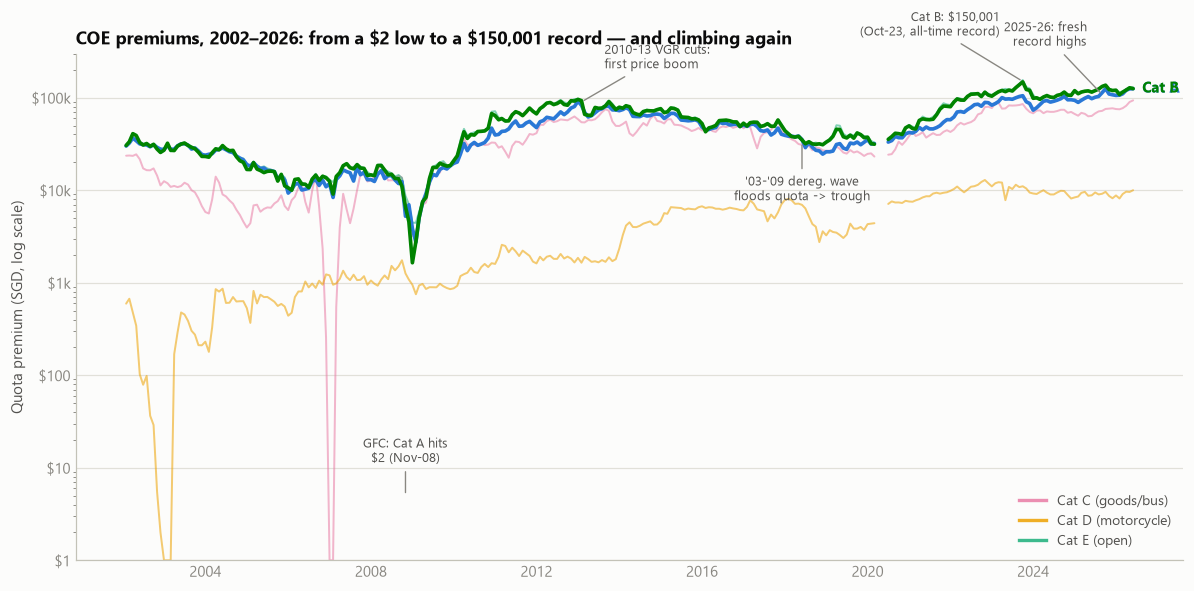

In [209]:
monthly_hist = (wide_cat[wide_cat.metric == "Quota Premium"]
                 .groupby(["vehicle_class", "month_dt"])["value"].mean()
                 .reset_index(name="premium"))

fig, ax = plt.subplots(figsize=(11, 5.5))
for cat in ["Category A", "Category B", "Category C", "Category D", "Category E"]:
    sub = monthly_hist[monthly_hist.vehicle_class == cat].sort_values("month_dt")
    is_focus = cat in FOCUS_CATS
    ax.plot(sub.month_dt, sub.premium, color=CAT_COLOR[cat],
            linewidth=2.4 if is_focus else 1.3,
            alpha=1.0 if is_focus else CONTEXT_ALPHA,
            solid_capstyle="round", zorder=3 if is_focus else 2,
            label=cat)

ax.set_yscale("log")
ax.set_ylim(1, 300000)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: ("${:,.0f}".format(x) if x < 1000 else "${:,.0f}k".format(x/1000))))
ax.set_title(r"COE premiums, 2002–2026: from a \$2 low to a \$150,001 record — and climbing again", loc="left")
ax.set_ylabel("Quota premium (SGD, log scale)")
style_ax(ax)

# labels at end of line instead of a legend box, for A & B
for cat in FOCUS_CATS:
    sub = monthly_hist[monthly_hist.vehicle_class == cat].sort_values("month_dt")
    ax.annotate(cat.replace("Category ", "Cat "), (sub.month_dt.iloc[-1], sub.premium.iloc[-1]),
                xytext=(6, 0), textcoords="offset points", va="center", fontsize=10,
                fontweight="bold", color=CAT_COLOR[cat], annotation_clip=False)
legend_handles = [Line2D([0], [0], color=CAT_COLOR[c], lw=2.2, alpha=max(CONTEXT_ALPHA, 0.85)) for c in ["Category C", "Category D", "Category E"]]
ax.legend(legend_handles, ["Cat C (goods/bus)", "Cat D (motorcycle)", "Cat E (open)"],
          loc="lower right", frameon=False, fontsize=9, labelcolor=INK_SECONDARY)

def annotate_event(ax, x, y, text, xytext=(0, 22), ha="center"):
    ax.annotate(text, (x, y), xytext=xytext, textcoords="offset points", ha=ha, fontsize=8.5,
                color=INK_SECONDARY, arrowprops=dict(arrowstyle="-", color=INK_MUTED, lw=0.9))

annotate_event(ax, pd.Timestamp("2008-11-01"), 5, "GFC: Cat A hits\n\\$2 (Nov-08)")
annotate_event(ax, pd.Timestamp("2013-02-01"), 90000, "2010-13 VGR cuts:\nfirst price boom", xytext=(15, 22), ha="left")
annotate_event(ax, pd.Timestamp("2018-06-01"), 33000, "'03-'09 dereg. wave\nfloods quota -> trough", xytext=(0, -38))
annotate_event(ax, pd.Timestamp("2023-10-01"), 150001, "Cat B: \\$150,001\n(Oct-23, all-time record)", xytext=(-15, 30), ha="right")
annotate_event(ax, pd.Timestamp("2025-09-01"), 108000, "2025-26: fresh\nrecord highs", xytext=(-10, 32), ha="right")

fig.tight_layout()
fig.savefig(OUT_CHARTS / "01_long_run_history.png", bbox_inches="tight")
plt.show()


4 moments stand out, each a real policy event not a guess:

- **2008-09 (GFC):** demand collapsed, quota flooded. Cat A fell to **\$2**.
- **2010-13:** govt cut Vehicle Growth Rate (3% → 0.5%). quota tightened, prices boomed.
- **2014-19:** an old boom cohort's COEs expired, flooding quota. prices fell for 6 yrs straight.
- **2022-today:** mirror image, quota tightened just as demand came back post covid. Cat B hit
  **\$150,001** (oct-2023 record). still climbing into 2025-26 — the live problem here basically.


### 4.2 all five categories side by side

before we narrow to A & B — how do all 5 compare on price, spread, quota size, demand? (from here
we use 2010-2026, `master`, not the full history)


In [210]:
desc = (master
        .groupby("vehicle_class")["premium"]
        .agg(n="count", mean="mean", median="median", std="std", skew="skew", min="min", max="max")
        .reindex(CAT_ORDER)
        .round({"mean": 0, "median": 0, "std": 0, "skew": 2, "min": 0, "max": 0}))
desc.to_csv(OUT_DATA / "premium_descriptive_stats.csv")
desc


,n,mean,median,std,skew,min,max
vehicle_class,,,,,,,
Category A,391,"61,675.00","56,989.00","25,422.00",0.52,18502,129000
Category B,391,"72,946.00","68,501.00","29,919.00",0.42,19190,150001
Category C,391,"49,884.00","48,889.00","17,961.00",0.36,19001,95000
Category D,391,"5,986.00","6,302.00","3,262.00",0.08,852,13189
Category E,391,"74,188.00","69,001.00","30,341.00",0.42,19889,158004


surprise: **E not B has the highest avg premium** (E can register any vehicle so it tracks
`max(A,B)`). D's in its own bracket, ~1/12th of B's price. C sits in the middle.


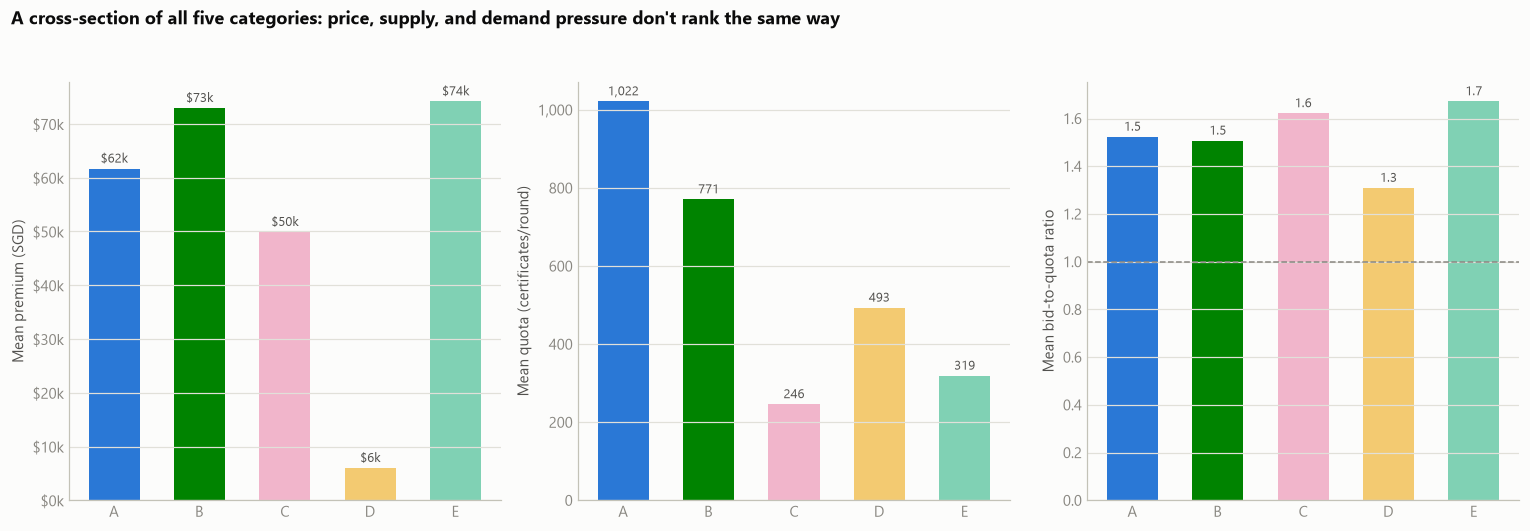

In [211]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.6))
metrics = [("premium", "Mean premium (SGD)", lambda x, _: "${:,.0f}k".format(x/1000)),
           ("quota", "Mean quota (certificates/round)", lambda x, _: f"{x:,.0f}"),
           ("bid_to_quota", "Mean bid-to-quota ratio", lambda x, _: f"{x:.1f}")]
for ax, (col, ylabel, fmt) in zip(axes, metrics):
    vals = master.groupby("vehicle_class")[col].mean().reindex(CAT_ORDER)
    bar_colors = [CAT_COLOR[c] for c in vals.index]
    bar_alpha = [1.0 if c in FOCUS_CATS else CONTEXT_ALPHA for c in vals.index]
    bars = ax.bar(range(5), vals.values, color=bar_colors, width=0.6)
    for b, a in zip(bars, bar_alpha):
        b.set_alpha(a)
    ax.set_xticks(range(5))
    ax.set_xticklabels([c.replace("Category ", "") for c in vals.index])
    ax.set_ylabel(ylabel)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt))
    style_ax(ax)
    for i, v in enumerate(vals.values):
        ax.annotate(fmt(v, None), (i, v), xytext=(0, 4), textcoords="offset points",
                    ha="center", fontsize=8.5, color=INK_SECONDARY)
    if col == "bid_to_quota":
        ax.axhline(1.0, color=INK_MUTED, linewidth=1, linestyle="--")
fig.suptitle("A cross-section of all five categories: price, supply, and demand pressure don't rank the same way",
             x=0.01, ha="left", fontsize=12, fontweight="bold", y=1.04)
fig.tight_layout()
fig.savefig(OUT_CHARTS / "02_all_categories_cross_section.png", bbox_inches="tight")
plt.show()


none of the 3 charts rank the categories the same way. A has the biggest quota despite a mid-high
price. C has the smallest quota despite mid-range price. price, quota size, demand pressure — 3
different things. part of why we model each category on its own (§6).


from here we narrow to A & B. one thing the chart above cant show — within just these two, the
price distribution isnt one bump, its several. why:


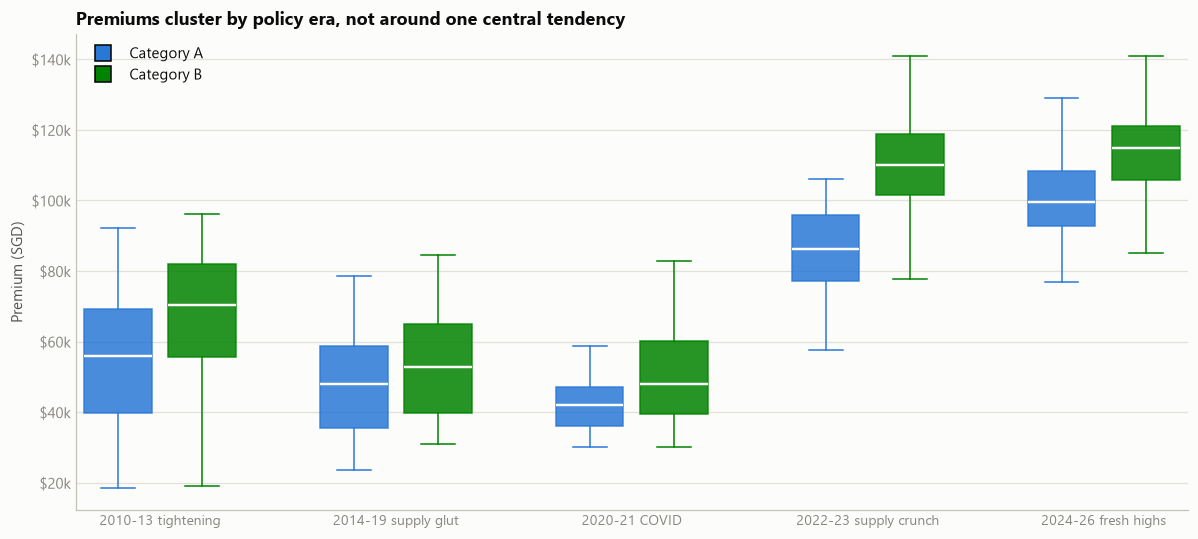

In [212]:
fig, ax = plt.subplots(figsize=(11, 5))
plot_df = master[master.vehicle_class.isin(FOCUS_CATS)].copy()
plot_df["era"] = pd.Categorical(plot_df["era"], categories=ERA_ORDER, ordered=True)

positions, box_data, colors, xt_labels = [], [], [], []
pos = 0
for era in ERA_ORDER:
    for cat in FOCUS_CATS:
        vals = plot_df[(plot_df.era == era) & (plot_df.vehicle_class == cat)]["premium"]
        box_data.append(vals.values)
        colors.append(CAT_COLOR[cat])
        positions.append(pos)
        pos += 1
    pos += 0.8  # gap between era groups

bp = ax.boxplot(box_data, positions=positions, widths=0.8, patch_artist=True, showfliers=False,
                 medianprops=dict(color="white", linewidth=1.6))
for patch, c in zip(bp["boxes"], colors):
    patch.set_facecolor(c)
    patch.set_alpha(0.85)
    patch.set_edgecolor(c)
for element in ["whiskers", "caps"]:
    for line, c in zip(bp[element], np.repeat(colors, 2)):
        line.set_color(c)

group_centers = [np.mean(positions[i*2:i*2+2]) for i in range(len(ERA_ORDER))]
ax.set_xticks(group_centers)
ax.set_xticklabels(ERA_ORDER, fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: "${:,.0f}k".format(x/1000)))
ax.set_title("Premiums cluster by policy era, not around one central tendency", loc="left")
ax.set_ylabel("Premium (SGD)")
style_ax(ax)
legend_handles = [Line2D([0], [0], marker="s", color="none", markerfacecolor=CAT_COLOR[c], markersize=10) for c in FOCUS_CATS]
ax.legend(legend_handles, FOCUS_CATS, loc="upper left", frameon=False, fontsize=9.5)
fig.tight_layout()
fig.savefig(OUT_CHARTS / "03_premium_distribution_by_era.png", bbox_inches="tight")
plt.show()


not one bump, 5 periods stacked together each w their own price range. B sits above A the whole
time, box usually taller too (B swings more, confirmed properly in §6.4)


### 4.3 quota moves in steps

quota changes almost every round (94.9% A, 94.1% B) not just quarterly. mostly small drift plus
the occasional big step. big steps are what matter for elasticity tho.


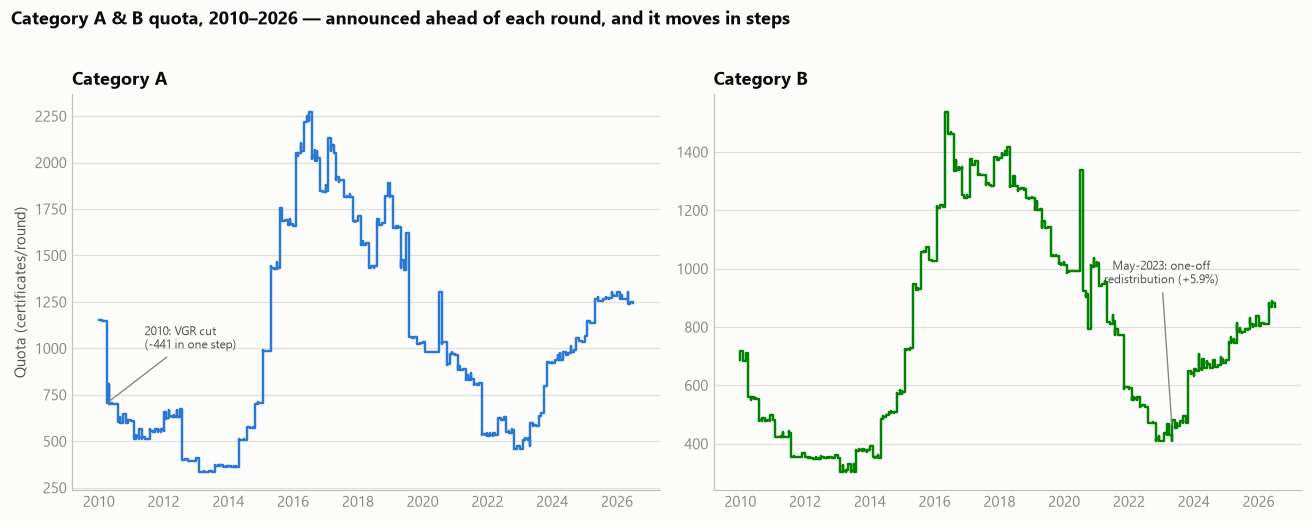

In [213]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), sharex=True)
for ax, cat in zip(axes, FOCUS_CATS):
    sub = master[master.vehicle_class == cat].sort_values("round_idx")
    ax.step(sub.month_dt, sub.quota, where="post", color=CAT_COLOR[cat], linewidth=1.6)
    ax.set_title(cat, loc="left")
    ax.set_ylabel("Quota (certificates/round)" if cat == "Category A" else "")
    style_ax(ax)
axes[0].annotate("2010: VGR cut\n(-441 in one step)", xy=(pd.Timestamp("2010-04-01"), 705),
                  xytext=(pd.Timestamp("2011-06-01"), 1000), fontsize=8, color=INK_SECONDARY,
                  arrowprops=dict(arrowstyle="-", color=INK_MUTED, lw=0.9))
axes[1].annotate("May-2023: one-off\nredistribution (+5.9%)", xy=(pd.Timestamp("2023-05-01"), 455),
                  xytext=(pd.Timestamp("2023-01-01"), 950), fontsize=8, color=INK_SECONDARY, ha="center",
                  arrowprops=dict(arrowstyle="-", color=INK_MUTED, lw=0.9))
fig.suptitle("Category A & B quota, 2010–2026 — announced ahead of each round, and it moves in steps", x=0.01, ha="left", fontsize=12, fontweight="bold", y=1.02)
fig.tight_layout()
fig.savefig(OUT_CHARTS / "04_quota_trends.png", bbox_inches="tight")
plt.show()


long quiet stretches then sharp jumps. the 2010 cut for A (-441 in one step) kicked off the 2010-13
boom. the may-2023 bump for B (+5.9%) is the one we test against real prices later in §8.3.


### 4.4 quota vs price: a confounded correlation

the relationship the brief actually asks about. no controls at all. if quota was the only driver
we'd expect a clean downward sloping cloud


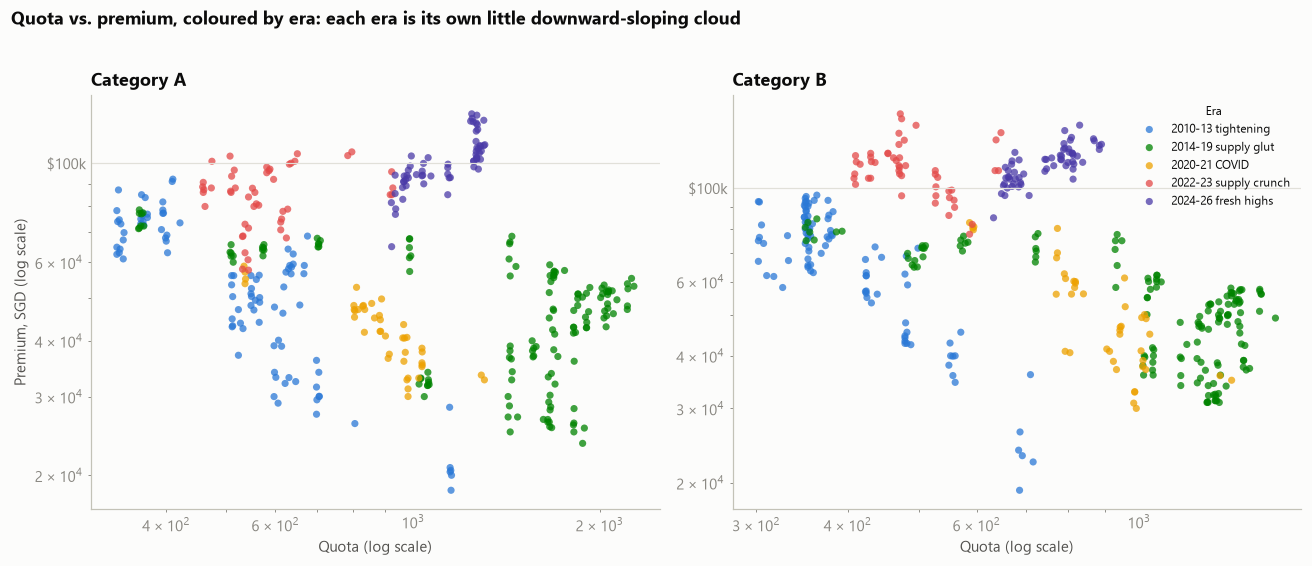

In [214]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, cat in zip(axes, FOCUS_CATS):
    sub = master[master.vehicle_class == cat]
    for era in ERA_ORDER:
        e = sub[sub.era == era]
        ax.scatter(e.quota, e.premium, s=22, color=ERA_COLOR[era], alpha=0.75, edgecolor="none", label=era)
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_title(cat, loc="left")
    ax.set_xlabel("Quota (log scale)")
    if cat == "Category A":
        ax.set_ylabel("Premium, SGD (log scale)")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: "${:,.0f}k".format(x/1000)))
    style_ax(ax)
axes[1].legend(loc="upper right", frameon=False, fontsize=8, title="Era", title_fontsize=8)
fig.suptitle("Quota vs. premium, coloured by era: each era is its own little downward-sloping cloud",
             x=0.01, ha="left", fontsize=12, fontweight="bold", y=1.02)
fig.tight_layout()
fig.savefig(OUT_CHARTS / "05_quota_vs_premium_by_era.png", bbox_inches="tight")
plt.show()


this chart is why Section 6 exists. within one era (one color) price slopes down as quota rises,
good. but *between* eras quota and price jump around way more than within one. a single line
thru everything mostly picks up that between-era noise not the real effect. fix: control for
era/year so the slope is measured within each color not across them.


In [215]:
naive = {}
for cat in FOCUS_CATS:
    sub = master[master.vehicle_class == cat]
    slope, intercept = np.polyfit(sub["ln_quota"], sub["ln_premium"], 1)
    r2 = np.corrcoef(sub["ln_quota"], sub["ln_premium"])[0, 1] ** 2
    naive[cat] = (round(slope, 3), round(r2, 3))
    print(f"{cat}: pooling all eras together, naive log-log slope = {slope:+.3f}, R² = {r2:.3f}")


Category A: pooling all eras together, naive log-log slope = -0.251, R² = 0.099
Category B: pooling all eras together, naive log-log slope = -0.461, R² = 0.253


confirmed. one line thru everything gives R² of just **0.10 (A) / 0.25 (B).** stopping here would
badly understate quota's effect


### 4.5 demand side: quota's never fully used

`bid_to_quota` (bids ÷ quota) = how hot demand is. youd think `bids_success` hits `quota` exactly
when demand's strong. almost never does tho.


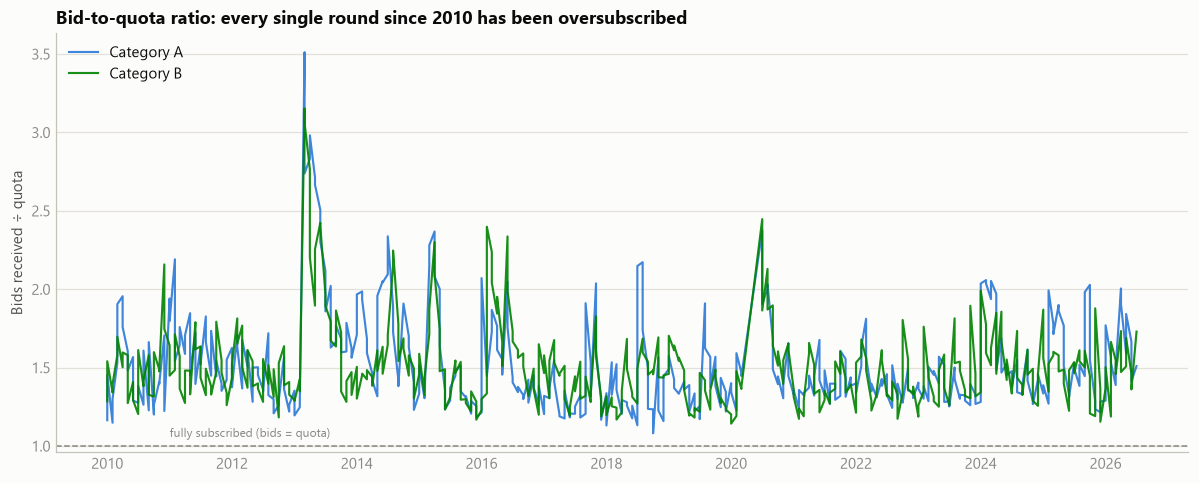

Share of rounds with bid_to_quota > 1 (oversubscribed), by era:
vehicle_class         Category A Category B
era                                        
2010-13 tightening          100%       100%
2014-19 supply glut         100%       100%
2020-21 COVID               100%       100%
2022-23 supply crunch       100%       100%
2024-26 fresh highs         100%       100%


In [216]:
fig, ax = plt.subplots(figsize=(11, 4.5))
for cat in FOCUS_CATS:
    sub = master[master.vehicle_class == cat].sort_values("round_idx")
    ax.plot(sub.month_dt, sub.bid_to_quota, color=CAT_COLOR[cat], linewidth=1.4, alpha=0.9, label=cat)
ax.axhline(1.0, color=INK_MUTED, linewidth=1, linestyle="--")
ax.annotate("fully subscribed (bids = quota)", xy=(pd.Timestamp("2011-01-01"), 1.0), xytext=(0, 6),
            textcoords="offset points", fontsize=8, color=INK_MUTED)
ax.set_title("Bid-to-quota ratio: every single round since 2010 has been oversubscribed", loc="left")
ax.set_ylabel("Bids received ÷ quota")
style_ax(ax)
ax.legend(loc="upper left", frameon=False, fontsize=9.5)
fig.tight_layout()
fig.savefig(OUT_CHARTS / "06_bid_to_quota_ratio.png", bbox_inches="tight")
plt.show()

print("Share of rounds with bid_to_quota > 1 (oversubscribed), by era:")
print(master[master.vehicle_class.isin(FOCUS_CATS)].pivot_table(
    index="era", columns="vehicle_class", values="bid_to_quota", aggfunc=lambda s: f"{(s>1).mean()*100:.0f}%"
).reindex(ERA_ORDER))


never touches "fully subscribed". every round in 16 yrs had more bids than certificates. demand's
always stretched. so any quota increase we simulate later lands on a market that wants more anyway.

next Q — does every certificate actually go to a winning bidder?


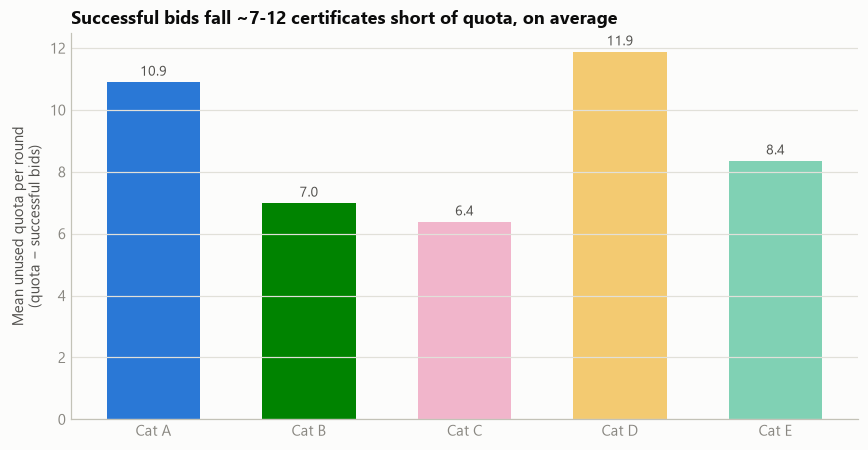

Share of rounds where successful bids < quota:
vehicle_class
Category A   84.10
Category B   75.20
Category C   75.40
Category D   85.20
Category E   82.90
Name: unused_quota, dtype: float64


In [217]:
fig, ax = plt.subplots(figsize=(8, 4.2))
unused_by_cat = master.groupby("vehicle_class")["unused_quota"].mean().reindex(
    ["Category A", "Category B", "Category C", "Category D", "Category E"])
bar_colors = [CAT_COLOR[c] for c in unused_by_cat.index]
bar_alpha = [1.0 if c in FOCUS_CATS else CONTEXT_ALPHA for c in unused_by_cat.index]
bars = ax.bar(range(5), unused_by_cat.values, color=bar_colors, width=0.6)
for b, a in zip(bars, bar_alpha):
    b.set_alpha(a)
ax.set_xticks(range(5))
ax.set_xticklabels([c.replace("Category ", "Cat ") for c in unused_by_cat.index])
ax.set_title("Successful bids fall ~7-12 certificates short of quota, on average", loc="left")
ax.set_ylabel("Mean unused quota per round\n(quota − successful bids)")
style_ax(ax)
for i, v in enumerate(unused_by_cat.values):
    ax.annotate(f"{v:.1f}", (i, v), xytext=(0, 4), textcoords="offset points", ha="center", fontsize=9, color=INK_SECONDARY)
fig.tight_layout()
fig.savefig(OUT_CHARTS / "07_unused_quota_by_category.png", bbox_inches="tight")
plt.show()

pct_undersub = master.groupby("vehicle_class")["unused_quota"].apply(lambda s: (s > 0).mean() * 100)
print("Share of rounds where successful bids < quota:")
print(pct_undersub.round(1))


no. successful bids fall short of quota in 75-85% of rounds, by 7-12 certs on avg. not a data
problem, just how the \$1-step bidding thing works. leftovers carry to next round.


### 4.6 two smaller effects - time of year, bidding round

small compared to §4.1's swings but consistent. worth controlling for.


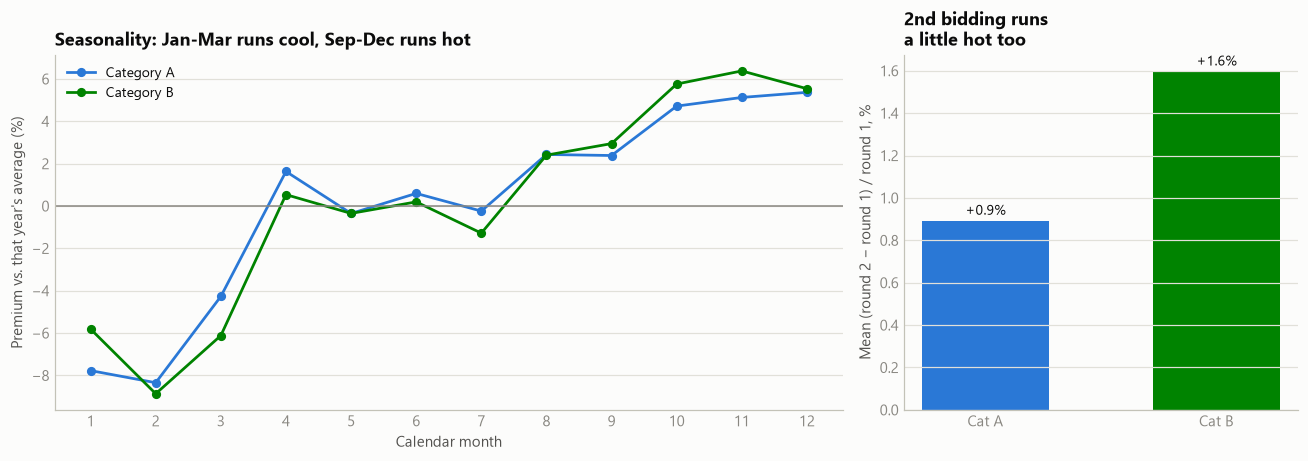

In [218]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.3), gridspec_kw={"width_ratios": [2, 1]})

ax = axes[0]
for cat in FOCUS_CATS:
    sub = master[master.vehicle_class == cat].copy()
    sub["resid"] = sub["ln_premium"] - sub.groupby("year")["ln_premium"].transform("mean")
    season = sub.groupby("month_num")["resid"].mean()
    ax.plot(season.index, season.values * 100, marker="o", markersize=5, color=CAT_COLOR[cat],
            linewidth=1.8, label=cat)
ax.axhline(0, color=INK_MUTED, linewidth=1)
ax.set_xticks(range(1, 13))
ax.set_xlabel("Calendar month")
ax.set_ylabel("Premium vs. that year's average (%)")
ax.set_title("Seasonality: Jan-Mar runs cool, Sep-Dec runs hot", loc="left")
style_ax(ax)
ax.legend(loc="upper left", frameon=False, fontsize=9)

ax = axes[1]
r1r2 = {}
for cat in FOCUS_CATS:
    sub = master[master.vehicle_class == cat]
    p = sub.pivot_table(index="month_dt", columns="bidding_no", values="premium").dropna()
    r1r2[cat] = ((p[2] - p[1]) / p[1] * 100).mean()
bars = ax.bar(range(2), [r1r2[c] for c in FOCUS_CATS], color=[CAT_COLOR[c] for c in FOCUS_CATS], width=0.55)
ax.set_xticks(range(2))
ax.set_xticklabels([c.replace("Category ", "Cat ") for c in FOCUS_CATS])
ax.set_title("2nd bidding runs\na little hot too", loc="left")
ax.set_ylabel("Mean (round 2 − round 1) / round 1, %")
style_ax(ax)
for i, cat in enumerate(FOCUS_CATS):
    ax.annotate(f"+{r1r2[cat]:.1f}%", (i, r1r2[cat]), xytext=(0, 4), textcoords="offset points", ha="center", fontsize=9)
fig.tight_layout()
fig.savefig(OUT_CHARTS / "08_seasonality_and_round_effect.png", bbox_inches="tight")
plt.show()


**left:** both run 4-9% below their year avg in jan-mar, 2-6% above in sep-dec. consistent enough
over 16 yrs to deserve a control.

**right:** month's 2nd round clears 0.9% (A) / 1.6% (B) higher than the 1st. small anchoring
effect. still worth controlling for.


### 4.7 how closely do A and B move together


In [219]:
a = master[master.vehicle_class == "Category A"].set_index(["month_dt", "bidding_no"])["premium"]
b = master[master.vehicle_class == "Category B"].set_index(["month_dt", "bidding_no"])["premium"]
ab = pd.concat([a.rename("A"), b.rename("B")], axis=1).dropna()
print(f"Correlation, levels:        {ab.corr().iloc[0,1]:.3f}")
print(f"Correlation, log levels:    {np.log(ab).corr().iloc[0,1]:.3f}")
print(f"Correlation, log-differences (round-to-round changes): {np.log(ab).diff().corr().iloc[0,1]:.3f}")


Correlation, levels:        0.956
Correlation, log levels:    0.961
Correlation, log-differences (round-to-round changes): 0.529


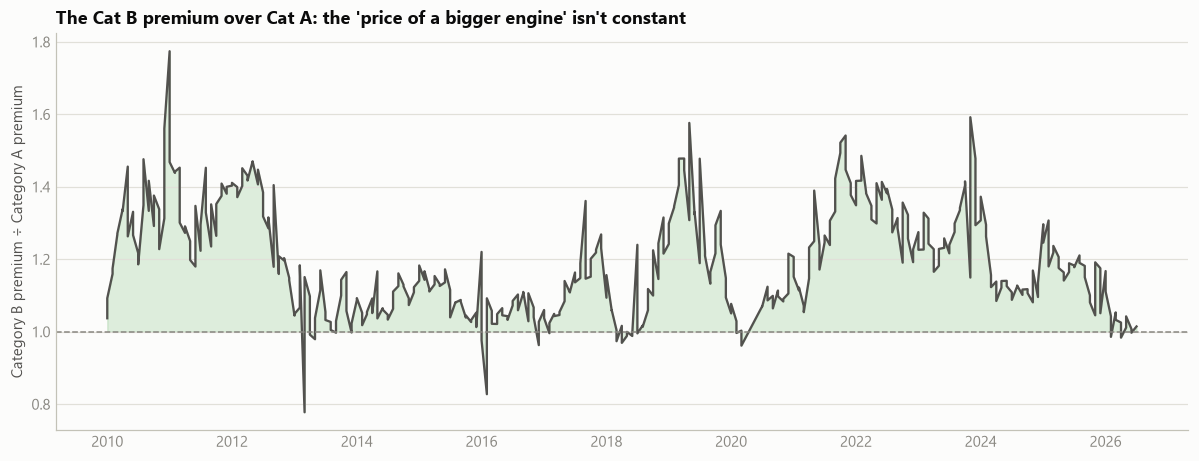

In [220]:
fig, ax = plt.subplots(figsize=(11, 4.3))
ratio = (ab["B"] / ab["A"]).reset_index()
ratio.columns = ["month_dt", "bidding_no", "ratio"]
ratio = ratio.sort_values(["month_dt", "bidding_no"])
ax.plot(ratio.month_dt, ratio.ratio, color=INK_SECONDARY, linewidth=1.5)
ax.axhline(1.0, color=INK_MUTED, linewidth=1, linestyle="--")
ax.fill_between(ratio.month_dt, 1.0, ratio.ratio, color=CAT_COLOR["Category B"], alpha=0.12)
ax.set_title("The Cat B premium over Cat A: the 'price of a bigger engine' isn't constant", loc="left")
ax.set_ylabel("Category B premium ÷ Category A premium")
style_ax(ax)
fig.tight_layout()
fig.savefig(OUT_CHARTS / "09_category_b_a_price_ratio.png", bbox_inches="tight")
plt.show()


very close in levels (corr 0.956) but drops to 0.529 in round to round changes. same big trend,
diff short run moves. B÷A ratio isnt a fixed markup either, dipped below 1.0 before and gone as
high as 1.77x. test if the two categories quotas affect each other in §6.5.


### 4.8 one check before modelling — does price drift?

does `ln(premium)` drift like a random walk in a way thatd make a regression misleading


In [221]:
from statsmodels.tsa.stattools import adfuller

adf_results = {}
print(f"{'':14s}{'ADF stat (level)':>18s}{'p-value':>12s}   {'ADF stat (Δ)':>15s}{'p-value':>12s}")
for cat in FOCUS_CATS:
    sub = master[master.vehicle_class == cat].sort_values("round_idx")
    lvl = adfuller(sub["ln_premium"], autolag="AIC")
    dif = adfuller(sub["ln_premium"].diff().dropna(), autolag="AIC")
    adf_results[cat] = {
        "level_stat": lvl[0], "level_p": lvl[1],
        "diff_stat": dif[0], "diff_p": dif[1],
    }
    print(f"{cat:14s}{lvl[0]:18.3f}{lvl[1]:12.4f}   {dif[0]:15.3f}{dif[1]:12.4f}")


                ADF stat (level)     p-value      ADF stat (Δ)     p-value
Category A                -1.010      0.7494            -8.067      0.0000
Category B                -1.451      0.5575           -10.832      0.0000


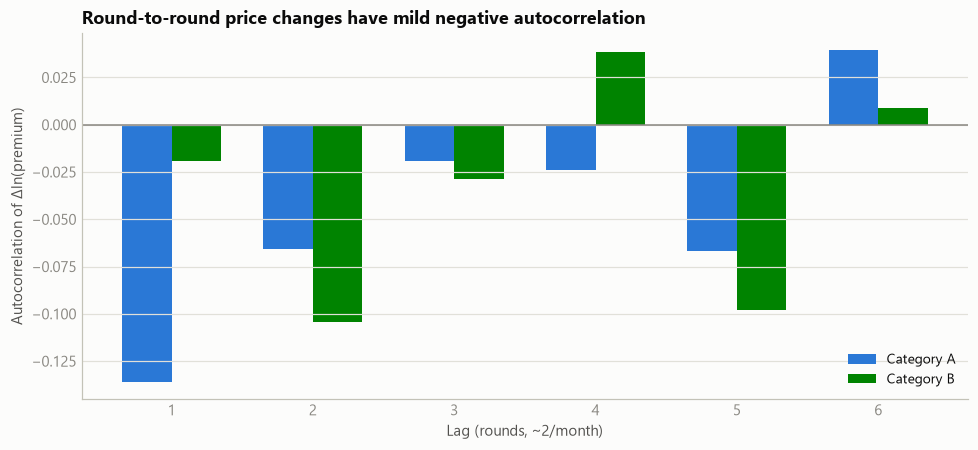

In [222]:
fig, ax = plt.subplots(figsize=(9, 4.2))
width = 0.35
lags = range(1, 7)
for offset, cat in zip([-width/2, width/2], FOCUS_CATS):
    sub = master[master.vehicle_class == cat].sort_values("round_idx")
    dlnp = sub["ln_premium"].diff().dropna()
    acfs = [dlnp.autocorr(lag=l) for l in lags]
    ax.bar([l + offset for l in lags], acfs, width=width, color=CAT_COLOR[cat], label=cat)
ax.axhline(0, color=INK_MUTED, linewidth=1)
ax.set_xticks(list(lags))
ax.set_xlabel("Lag (rounds, ~2/month)")
ax.set_ylabel("Autocorrelation of Δln(premium)")
ax.set_title("Round-to-round price changes have mild negative autocorrelation", loc="left")
style_ax(ax)
ax.legend(loc="lower right", frameon=False, fontsize=9)
fig.tight_layout()
fig.savefig(OUT_CHARTS / "10_price_change_autocorrelation.png", bbox_inches="tight")
plt.show()


yea it drifts (p=0.75/0.56 on levels) but the round-to-round change doesnt (p<0.0001). two fixes we
use in Sec 6 — control for year (M3/M4), use HAC standard errors (residuals correlated round to
round)


### 4.9 is it fair to focus on just A & B?

check each category's share of quota and "COE spend" (bids × premium)


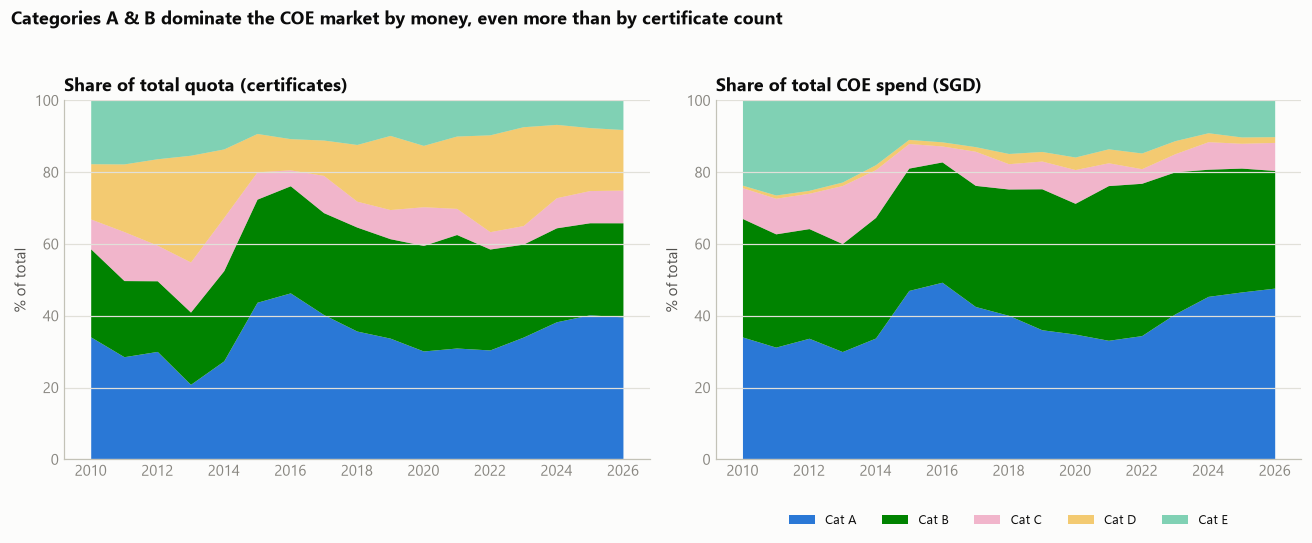

Total COE spend, all 5 categories combined, SGD billions/year (2026 is partial-year, Jan-Jul):
year
2010   1.55
2011   1.96
2012   2.32
2013   2.11
2014   2.40
2015   4.15
2016   4.85
2017   4.88
2018   3.16
2019   2.65
2020   1.85
2021   2.70
2022   2.85
2023   3.52
2024   4.63
2025   6.45
2026   3.98
Name: spend, dtype: float64

A+B combined share of total COE spend: 67% (2010) -> 80% (2026 YTD)


In [223]:
all_cats = master.copy()
all_cats["spend"] = all_cats["bids_success"] * all_cats["premium"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
for ax, value_col, title in zip(axes, ["quota", "spend"], ["Share of total quota (certificates)", "Share of total COE spend (SGD)"]):
    by_year = all_cats.groupby(["year", "vehicle_class"])[value_col].sum().unstack()[CAT_ORDER]
    share = by_year.div(by_year.sum(axis=1), axis=0) * 100
    share.to_csv(OUT_DATA / f"category_share_of_{value_col}_by_year.csv")
    bottoms = np.zeros(len(share))
    for cat in CAT_ORDER:
        alpha = 1.0 if cat in FOCUS_CATS else CONTEXT_ALPHA
        ax.fill_between(share.index, bottoms, bottoms + share[cat], color=CAT_COLOR[cat], alpha=alpha,
                         label=cat.replace("Category ", "Cat "), linewidth=0)
        bottoms += share[cat].values
    ax.set_title(title, loc="left")
    ax.set_ylim(0, 100)
    ax.set_ylabel("% of total")
    style_ax(ax)
axes[1].legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=5, frameon=False, fontsize=8.5)
fig.suptitle("Categories A & B dominate the COE market by money, even more than by certificate count",
             x=0.01, ha="left", fontsize=12, fontweight="bold", y=1.03)
fig.tight_layout()
fig.savefig(OUT_CHARTS / "11_category_market_share.png", bbox_inches="tight")
plt.show()

total_spend = all_cats.groupby("year")["spend"].sum() / 1e9
print("Total COE spend, all 5 categories combined, SGD billions/year (2026 is partial-year, Jan-Jul):")
print(total_spend.round(2))
ab_share_spend = all_cats[all_cats.vehicle_class.isin(FOCUS_CATS)].groupby("year")["spend"].sum() / all_cats.groupby("year")["spend"].sum() * 100
print(f"\nA+B combined share of total COE spend: {ab_share_spend.loc[2010]:.0f}% (2010) -> {ab_share_spend.loc[2026]:.0f}% (2026 YTD)")


yea — A & B are 55-70% of certificates but **65-80% of total spend**, and growing. thats the money
so thats where the modelling effort goes


### 4.10 how much of the "record high" is just inflation?

\$150,001 is a record in *nominal* dollars. but a 2010 dollar bought more than today's does. use CPI
([SingStat, 2024=100](https://data.gov.sg/datasets/d_bdaff844e3ef89d39fceb962ff8f0791/view)) to
check if "record" still holds up in todays-dollar terms.


CPI (2024=100) series: Jan-1961 to Jul-2026 (last 2 months forward-filled from May-2026, not yet published)


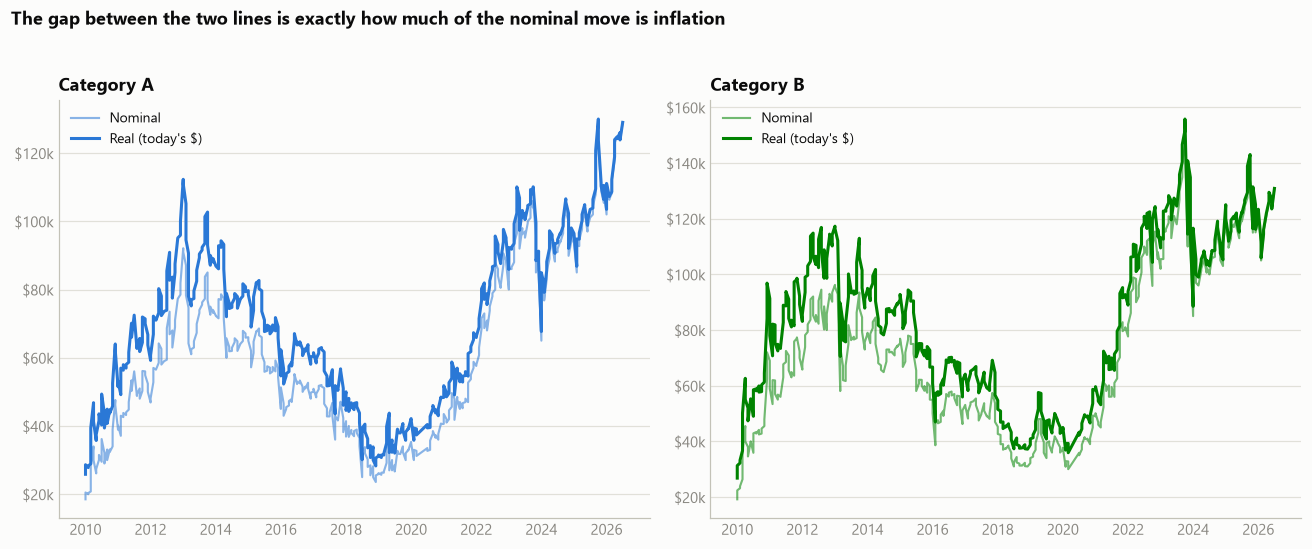

Cumulative CPI inflation since:
  2010-01: 39.7% cumulative inflation to today
  2013-01: 21.9% cumulative inflation to today
  2023-10: 3.9% cumulative inflation to today

2010 -> 2026 growth, nominal vs real (annual averages):
  Category A: nominal +283%, real +182%  (inflation 'explains' ~36% of that 283-point nominal move)
  Category B: nominal +202%, real +123%  (inflation 'explains' ~39% of that 202-point nominal move)

Category A's REAL (inflation-adjusted) all-time high was actually 2025-10 round 1 (\$128,105 nominal, \$129,981 in today's dollars) -- not the most recent nominal print.


In [224]:
cpi_raw = pd.read_csv(DATA_DIR / "ConsumerPriceIndexCPIMonthly.csv")
cpi_month_cols = [c for c in cpi_raw.columns if c != "DataSeries"]
all_items = cpi_raw[cpi_raw["DataSeries"].str.strip() == "All Items"]
cpi_long = all_items.melt(id_vars="DataSeries", value_vars=cpi_month_cols, var_name="month_str", value_name="cpi")
cpi_long["cpi"] = pd.to_numeric(cpi_long["cpi"], errors="coerce")
cpi_long["month_dt"] = pd.to_datetime(cpi_long["month_str"], format="%Y%b")
cpi_long = cpi_long[["month_dt", "cpi"]].sort_values("month_dt").reset_index(drop=True)
# ffill the last 1-2 months, cpi not published yet, doesnt matter much
full_range = pd.date_range(cpi_long.month_dt.min(), master.month_dt.max(), freq="MS")
cpi_long = cpi_long.set_index("month_dt").reindex(full_range).ffill().rename_axis("month_dt").reset_index()
latest_cpi = cpi_long["cpi"].iloc[-1]
print(f"CPI (2024=100) series: {cpi_long.month_dt.min():%b-%Y} to {cpi_long.month_dt.max():%b-%Y} "
      f"(last 2 months forward-filled from {full_range[-3]:%b-%Y}, not yet published)")

master = master.merge(cpi_long, on="month_dt", how="left")
master["premium_real"] = master["premium"] * (latest_cpi / master["cpi"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), sharex=True)
for ax, cat in zip(axes, FOCUS_CATS):
    sub = master[master.vehicle_class == cat].sort_values("round_idx")
    ax.plot(sub.month_dt, sub.premium, color=CAT_COLOR[cat], alpha=CONTEXT_ALPHA, linewidth=1.4, label="Nominal")
    ax.plot(sub.month_dt, sub.premium_real, color=CAT_COLOR[cat], linewidth=2.0, label="Real (today's $)")
    ax.set_title(cat, loc="left")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: "${:,.0f}k".format(x/1000)))
    style_ax(ax)
    ax.legend(loc="upper left", frameon=False, fontsize=9)
fig.suptitle("The gap between the two lines is exactly how much of the nominal move is inflation",
             x=0.01, ha="left", fontsize=12, fontweight="bold", y=1.03)
fig.tight_layout()
fig.savefig(OUT_CHARTS / "12_nominal_vs_real_premium.png", bbox_inches="tight")
plt.show()

print("Cumulative CPI inflation since:")
for ym in ["2010-01-01", "2013-01-01", "2023-10-01"]:
    c = cpi_long.loc[cpi_long.month_dt == ym, "cpi"].iloc[0]
    print(f"  {ym[:7]}: {(latest_cpi/c - 1)*100:.1f}% cumulative inflation to today")

print("\n2010 -> 2026 growth, nominal vs real (annual averages):")
inflation_decomposition = {}
for cat in FOCUS_CATS:
    sub = master[master.vehicle_class == cat]
    yr = sub.groupby("year")[["premium", "premium_real"]].mean()
    nom_g = yr.loc[2026, "premium"] / yr.loc[2010, "premium"] - 1
    real_g = yr.loc[2026, "premium_real"] / yr.loc[2010, "premium_real"] - 1
    inflation_decomposition[cat] = {
        "nominal_growth_2010_2026": nom_g,
        "real_growth_2010_2026": real_g,
        "pct_of_nominal_move_explained_by_inflation": (1 - real_g / nom_g),
    }
    print(f"  {cat}: nominal {nom_g*100:+.0f}%, real {real_g*100:+.0f}%  "
          f"(inflation 'explains' ~{(1 - real_g/nom_g)*100:.0f}% of that {nom_g*100:.0f}-point nominal move)")

hi_real_A = master[master.vehicle_class == "Category A"].pipe(lambda d: d.loc[d.premium_real.idxmax()])
print(f"\nCategory A's REAL (inflation-adjusted) all-time high was actually {hi_real_A['month']} "
      f"round {hi_real_A['bidding_no']} (\\${hi_real_A['premium']:,.0f} nominal, "
      f"\\${hi_real_A['premium_real']:,.0f} in today's dollars) -- not the most recent nominal print.")


inflation's real but not the whole story. cumulative inflation ~40% since 2010. Cat A is +280%
nominal, still **+180% real**. Cat B: +200% nominal, +120% real. about a third of the rise is
inflation, two thirds genuine.

does this change the elasticity model? **no.** §6.2 shows it barely moves whether nominal or
cpi-adjusted. the year control already soaks up inflation anyway.


## 5. Feature Engineering — Two Feature Sets, Two Jobs

explaining and forecasting play by diff rules. so two feature sets off the same `master` table:

| | **For explaining** (§6) | **For forecasting** (§7) |
|---|---|---|
| This round's `bid_to_quota`? | Yes | No — not known yet |
| Announced `quota`? | Yes | Yes |
| Time controls | year/quarter/round dummies | numeric trend + calendar |
| Main inputs | `ln_quota`, `ln_btq`, `C(year/quarter/bidding_no)` | `quota`, `pqp`, lags |

forecasting also needs a **chronological** train/test split. never random, or the model peeks at
the future.


In [225]:
ml_df = master[master.vehicle_class.isin(FOCUS_CATS)].copy()
ml_df = ml_df.dropna(subset=["premium_lag1", "bid_to_quota_lag1", "pqp"])  # drops 2 rounds right after covid gap
ml_df["cat_code"] = (ml_df["vehicle_class"] == "Category B").astype(int)

N_TEST_ROUNDS = 48  # ~2 yrs held out per category
cutoff = ml_df.groupby("vehicle_class")["round_idx"].transform("max") - N_TEST_ROUNDS
train, test = ml_df[ml_df.round_idx <= cutoff].copy(), ml_df[ml_df.round_idx > cutoff].copy()

print(f"Train: {len(train)} rounds, {train.month_dt.min():%b-%Y} to {train.month_dt.max():%b-%Y}")
print(f"Test:  {len(test)} rounds, {test.month_dt.min():%b-%Y} to {test.month_dt.max():%b-%Y}  <- held out, never touched until §7.2")


Train: 682 rounds, Jan-2010 to Jun-2024
Test:  96 rounds, Jul-2024 to Jun-2026  <- held out, never touched until §7.2


test period is jul-2024 to jun-2026, the hardest stretch we got — both categories hit price levels
never seen in training. picked on purpose. fair test not an easy one.


## 6. Explanatory Modelling — Quantifying Quota Elasticity

**goal:** estimate elasticity, the % change in price per 1% change in quota, demand held steady.

**why log-log?** turns COE's %-terms price moves into a straight line so slope = elasticity
directly.

**why 4 steps (M1→M4)?** so u can see how much each control matters:
- M1 plain: `ln_premium ~ ln_quota`
- M2 + demand: `+ ln_btq`
- M3 + year control: `+ C(year)` — the fix §4.4 said we needed
- M4 final: `+ C(quarter) + C(bidding_no)`

**why HAC errors?** §4.8 found the series correlated round to round. textbook errors wouldve made
us overconfident.


In [226]:
import statsmodels.formula.api as smf
import statsmodels.api as sm

HAC_LAGS = 6

def fit_hac(formula, data):
    return smf.ols(formula, data=data).fit(cov_type="HAC", cov_kwds={"maxlags": HAC_LAGS})

progression, final_models = {}, {}
for cat in FOCUS_CATS:
    d = master[master.vehicle_class == cat].copy()
    d["year_c"], d["quarter_c"], d["bidding_no_c"] = d["year"].astype(str), d["quarter"].astype(str), d["bidding_no"].astype(str)

    fits = {
        "M1 naive":            fit_hac("ln_premium ~ ln_quota", d),
        "M2 + demand":         fit_hac("ln_premium ~ ln_quota + ln_btq", d),
        "M3 + year FE":        fit_hac("ln_premium ~ ln_quota + ln_btq + C(year_c)", d),
        "M4 final":            fit_hac("ln_premium ~ ln_quota + ln_btq + C(year_c) + C(quarter_c) + C(bidding_no_c)", d),
    }
    progression[cat] = fits
    final_models[cat] = fits["M4 final"]

    print(f"\n=== {cat} ===")
    print(f"{'model':14s}{'elasticity (ln_quota coef)':>28s}{'std err':>10s}{'R2':>8s}")
    for name, m in fits.items():
        print(f"{name:14s}{m.params['ln_quota']:28.3f}{m.bse['ln_quota']:10.3f}{m.rsquared:8.3f}")



=== Category A ===
model           elasticity (ln_quota coef)   std err      R2
M1 naive                            -0.251     0.069   0.099
M2 + demand                         -0.235     0.074   0.103
M3 + year FE                        -0.313     0.066   0.935
M4 final                            -0.310     0.046   0.945

=== Category B ===
model           elasticity (ln_quota coef)   std err      R2
M1 naive                            -0.461     0.071   0.253
M2 + demand                         -0.463     0.071   0.253
M3 + year FE                        -0.432     0.118   0.925
M4 final                            -0.436     0.089   0.937


Cat A: -0.251 → **-0.310** once year controls kick in, R² 0.10 → 0.945. Cat B: R² jumps the same
way but coefficient barely moves (-0.461 → -0.436), plain estimate was already close. either way
year control makes the signal way clearer.


### 6.2 the headline number, and how far we trust it


In [227]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

summary_rows = []
for cat in FOCUS_CATS:
    m = final_models[cat]
    ci = m.conf_int().loc["ln_quota"]
    summary_rows.append({
        "category": cat, "elasticity": m.params["ln_quota"], "std_err": m.bse["ln_quota"],
        "ci_low": ci[0], "ci_high": ci[1], "p_value": m.pvalues["ln_quota"], "R2": m.rsquared, "n": int(m.nobs),
    })
summary_df = pd.DataFrame(summary_rows).set_index("category").round(4)
summary_df.to_csv(OUT_DATA / "elasticity_estimates.csv")
summary_df


,elasticity,std_err,ci_low,ci_high,p_value,R2,n
category,,,,,,,
Category A,-0.31,0.05,-0.40,-0.22,0.00,0.95,391
Category B,-0.44,0.09,-0.61,-0.26,0.00,0.94,391


In [228]:
print("Variance Inflation Factor (multicollinearity check) for the two continuous regressors:")
for cat in FOCUS_CATS:
    m = final_models[cat]
    X, names = m.model.exog, m.model.exog_names
    for target in ["ln_quota", "ln_btq"]:
        j = names.index(target)
        print(f"  {cat:12s} {target:10s} VIF = {variance_inflation_factor(X, j):.1f}")

print("\nDurbin-Watson statistic on residuals (near 2 = no autocorrelation; well below 2 = positive autocorrelation):")
for cat in FOCUS_CATS:
    print(f"  {cat}: {sm.stats.stattools.durbin_watson(final_models[cat].resid):.3f}")


Variance Inflation Factor (multicollinearity check) for the two continuous regressors:
  Category A   ln_quota   VIF = 10.9
  Category A   ln_btq     VIF = 1.5
  Category B   ln_quota   VIF = 17.6
  Category B   ln_btq     VIF = 1.3

Durbin-Watson statistic on residuals (near 2 = no autocorrelation; well below 2 = positive autocorrelation):
  Category A: 0.755
  Category B: 0.598


**headline: A ≈ -0.31, B ≈ -0.44**, both p<0.001. 10% more quota → ~3.1% (A) / 4.4% (B) lower price.
both well under 1, demand doesnt swing much with quota.

2 caveats — VIF is high (11-18 from 16 year controls), widens the std error but doesnt bias the
number. durbin-watson confirms round to round correlation, why we use HAC.

**does inflation leak in?** no, `C(year)` already absorbs it. check — refit on cpi-deflated prices:


In [229]:
# premium_real was already computed in §4.10, just log it here
master["ln_premium_real"] = np.log(master["premium_real"])

real_elasticity_check = {}
for cat in FOCUS_CATS:
    d = master[master.vehicle_class == cat].copy()
    d["year_c"], d["quarter_c"], d["bidding_no_c"] = d["year"].astype(str), d["quarter"].astype(str), d["bidding_no"].astype(str)
    m_real = fit_hac("ln_premium_real ~ ln_quota + ln_btq + C(year_c) + C(quarter_c) + C(bidding_no_c)", d)
    m_nom = final_models[cat]
    real_elasticity_check[cat] = {"nominal": m_nom.params["ln_quota"], "real": m_real.params["ln_quota"]}
    print(f"{cat}: nominal elasticity = {m_nom.params['ln_quota']:+.4f} (se={m_nom.bse['ln_quota']:.4f})  |  "
          f"real (CPI-deflated) elasticity = {m_real.params['ln_quota']:+.4f} (se={m_real.bse['ln_quota']:.4f})")


Category A: nominal elasticity = -0.3103 (se=0.0464)  |  real (CPI-deflated) elasticity = -0.2974 (se=0.0446)
Category B: nominal elasticity = -0.4363 (se=0.0891)  |  real (CPI-deflated) elasticity = -0.4086 (se=0.0863)


confirmed, barely moves (A: -0.310 → -0.297, B: -0.436 → -0.409). **not an inflation artefact then.**


### 6.3 does it hold up on changes not levels?

year controls fix the drift problem (§4.8) by controlling for trend. differencing fixes the same
problem a diff way, by removing the trend. if they agree thats good evidence.


In [230]:
diff_results = {}
for cat in FOCUS_CATS:
    d = master[master.vehicle_class == cat].sort_values("round_idx").copy()
    d["d_ln_premium"] = d["ln_premium"].diff()
    d["d_ln_quota"] = d["ln_quota"].diff()
    d["d_ln_btq"] = d["ln_btq"].diff()
    d["quarter_c"] = d["quarter"].astype(str)
    d = d.dropna(subset=["d_ln_premium", "d_ln_quota", "d_ln_btq"])
    m = fit_hac("d_ln_premium ~ d_ln_quota + d_ln_btq + C(quarter_c)", d)
    diff_results[cat] = m
    print(f"{cat}: Δ-spec coefficient on Δln(quota) = {m.params['d_ln_quota']:+.3f} "
          f"(se={m.bse['d_ln_quota']:.3f}, p={m.pvalues['d_ln_quota']:.4f})  |  "
          f"levels-spec (§6.2) = {final_models[cat].params['ln_quota']:+.3f}")


Category A: Δ-spec coefficient on Δln(quota) = -0.117 (se=0.052, p=0.0252)  |  levels-spec (§6.2) = -0.310
Category B: Δ-spec coefficient on Δln(quota) = -0.201 (se=0.090, p=0.0255)  |  levels-spec (§6.2) = -0.436


both agree on sign and significance. differencing gives a smaller number (-0.12/-0.20 vs
-0.31/-0.44), expected since it only catches the immediate reaction. two numbers bracket a
believable range.


### 6.4 is B really more sensitive to quota than A?

§6.2's -0.31 vs -0.44 hints at it. but eyeballing 2 numbers isnt a real test, so stack A and B into
one model w a category × quota interaction term. formal test.


In [231]:
pooled = master[master.vehicle_class.isin(FOCUS_CATS)].copy()
pooled["year_c"], pooled["quarter_c"], pooled["bidding_no_c"] = pooled["year"].astype(str), pooled["quarter"].astype(str), pooled["bidding_no"].astype(str)

m_pooled = smf.ols(
    "ln_premium ~ ln_quota + ln_btq + C(vehicle_class) + C(vehicle_class):ln_quota "
    "+ C(year_c) + C(quarter_c) + C(bidding_no_c)",
    data=pooled,
).fit(cov_type="HAC", cov_kwds={"maxlags": HAC_LAGS})

interaction = "C(vehicle_class)[T.Category B]:ln_quota"
print(f"Category A elasticity (baseline):        {m_pooled.params['ln_quota']:+.3f}")
print(f"Category B *additional* elasticity:      {m_pooled.params[interaction]:+.3f}  "
      f"(p={m_pooled.pvalues[interaction]:.4f})")
print(f"=> Category B implied elasticity:        {m_pooled.params['ln_quota'] + m_pooled.params[interaction]:+.3f}")
print(f"Pooled model R2: {m_pooled.rsquared:.3f}, n={int(m_pooled.nobs)}")


Category A elasticity (baseline):        -0.245
Category B *additional* elasticity:      -0.112  (p=0.0029)
=> Category B implied elasticity:        -0.357
Pooled model R2: 0.931, n=782


yes — real, not noise (interaction term -0.11, p ≈ 0.003). B genuinely more sensitive to quota than
A. makes sense — same supply shift moves price more against a steeper demand curve, and B buyers
(bigger, more discretionary cars) probably got fewer substitutes than A's.


### 6.5 does one category's quota affect the other's price?

do would be B buyers switch to A if A's quota loosens (and vice versa)? put both categories' quota
into each model n check.


In [232]:
wideA = master[master.vehicle_class == "Category A"][["month_dt", "bidding_no", "ln_quota", "ln_btq"]].rename(
    columns={"ln_quota": "ln_quota_A", "ln_btq": "ln_btq_A"})
wideB = master[master.vehicle_class == "Category B"][["month_dt", "bidding_no", "ln_quota", "ln_btq"]].rename(
    columns={"ln_quota": "ln_quota_B", "ln_btq": "ln_btq_B"})
cross_base = wideA.merge(wideB, on=["month_dt", "bidding_no"], how="inner")

cross_results = {}
for cat, own, other in [("Category A", "A", "B"), ("Category B", "B", "A")]:
    d = master[master.vehicle_class == cat][["month_dt", "bidding_no", "ln_premium", "year", "quarter"]].merge(
        cross_base, on=["month_dt", "bidding_no"], how="inner")
    d["year_c"], d["quarter_c"], d["bidding_no_c"] = d["year"].astype(str), d["quarter"].astype(str), d["bidding_no"].astype(str)
    m = fit_hac(f"ln_premium ~ ln_quota_{own} + ln_quota_{other} + ln_btq_{own} "
                f"+ C(year_c) + C(quarter_c) + C(bidding_no_c)", d)
    cross_results[cat] = {"own_elasticity": m.params[f"ln_quota_{own}"], "own_p": m.pvalues[f"ln_quota_{own}"],
                           "other_elasticity": m.params[f"ln_quota_{other}"], "other_p": m.pvalues[f"ln_quota_{other}"]}
    print(f"{cat}: own-quota elasticity = {m.params[f'ln_quota_{own}']:+.3f} (p={m.pvalues[f'ln_quota_{own}']:.4f})  |  "
          f"other-category quota elasticity = {m.params[f'ln_quota_{other}']:+.3f} (p={m.pvalues[f'ln_quota_{other}']:.4f})")


Category A: own-quota elasticity = -0.294 (p=0.0005)  |  other-category quota elasticity = -0.030 (p=0.7999)


Category B: own-quota elasticity = -0.284 (p=0.0095)  |  other-category quota elasticity = -0.133 (p=0.1812)


nope, not significant either way (p=0.80, p=0.18). **treat A and B as separate levers.**


## 7. Predictive Modelling — Forecasting COE Prices

Section 6 explained quota's effect. this is the brief's other half — using only info we'd have
**before** a round opens, how well can we predict price? 4 candidates:

1. **simple persistence** — this round = last round's price. tough baseline since price drifts (§4.8)
2. **PQP as predictor** — free, already published
3. **Gradient Boosting** — picks up nonlinearities w/o us specifying them by hand
4. **our hybrid** — last price adjusted by Sec 6's elasticity for the announced quota change


In [233]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score

FEATURES = ["ln_quota", "quota", "pqp", "ln_pqp", "premium_lag1", "ln_premium_lag1",
            "bid_to_quota_lag1", "ln_btq_lag1", "quota_lag1", "month_num", "quarter",
            "bidding_no", "year", "round_idx", "cat_code"]

gbm = GradientBoostingRegressor(n_estimators=300, max_depth=3, learning_rate=0.05, subsample=0.8, random_state=42)
gbm.fit(train[FEATURES], train["ln_premium"])
pred_gbm = np.exp(gbm.predict(test[FEATURES]))
actual = np.exp(test["ln_premium"])

ELASTICITY = {cat: final_models[cat].params["ln_quota"] for cat in FOCUS_CATS}
test["elasticity"] = test["vehicle_class"].map(ELASTICITY)
pred_hybrid = test["premium_lag1"] * (test["quota"] / test["quota_lag1"]) ** test["elasticity"]

def metrics(actual, pred):
    return pd.Series({
        "MAE": mean_absolute_error(actual, pred),
        "RMSE": np.sqrt(mean_squared_error(actual, pred)),
        "MAPE_%": mean_absolute_percentage_error(actual, pred) * 100,
        "R2": r2_score(actual, pred),
    })

results = pd.DataFrame({
    "1. Naive (last round)": metrics(actual, test["premium_lag1"]),
    "2. PQP as predictor": metrics(actual, test["pqp"]),
    "3. Gradient Boosting": metrics(actual, pred_gbm),
    "4. Hybrid (persistence + elasticity)": metrics(actual, pred_hybrid),
}).T.round({"MAE": 0, "RMSE": 0, "MAPE_%": 2, "R2": 3})
results.to_csv(OUT_DATA / "forecast_model_comparison.csv")
results


,MAE,RMSE,MAPE_%,R2
1. Naive (last round),"4,036.00","5,294.00",3.61,0.80
2. PQP as predictor,"3,987.00","5,257.00",3.55,0.80
3. Gradient Boosting,"4,868.00","6,146.00",4.28,0.73
4. Hybrid (persistence + elasticity),"4,203.00","5,429.00",3.75,0.79


simple wins. neither GBM nor our hybrid beats "price wont change much" on this 2-yr hold-out. not
a bug, honest finding. why, below.


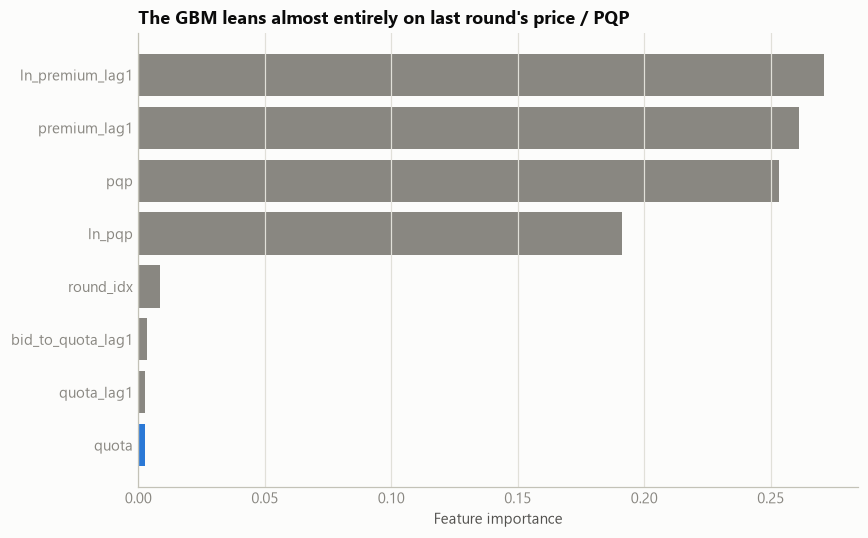

Combined importance of premium_lag1 + ln_premium_lag1 + pqp + ln_pqp: 97.7%
Importance of quota / ln_quota (the policy lever): 0.4%


In [234]:
importances = pd.Series(gbm.feature_importances_, index=FEATURES).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 5))
top = importances.head(8)
colors_imp = [CAT_COLOR["Category A"] if f in ("ln_quota", "quota") else INK_MUTED for f in top.index]
ax.barh(range(len(top)), top.values[::-1], color=colors_imp[::-1])
ax.set_yticks(range(len(top)))
ax.set_yticklabels(top.index[::-1])
ax.set_title("The GBM leans almost entirely on last round's price / PQP", loc="left")
ax.set_xlabel("Feature importance")
style_ax(ax, ygrid_only=False)
ax.grid(axis="y", visible=False)
fig.tight_layout()
fig.savefig(OUT_CHARTS / "13_gbm_feature_importance.png", bbox_inches="tight")
plt.show()

print(f"Combined importance of premium_lag1 + ln_premium_lag1 + pqp + ln_pqp: "
      f"{importances[['premium_lag1','ln_premium_lag1','pqp','ln_pqp']].sum()*100:.1f}%")
print(f"Importance of quota / ln_quota (the policy lever): {importances[['quota','ln_quota']].sum()*100:.1f}%")


### 7.3 why simple wins, what to actually use

1. **price behaves like a random walk** (§4.8). "no change" is a famously hard benchmark to beat.
2. **GBM agrees** — 98% of its importance sits on last price/PQP, only 0.4% on quota. not a
   contradiction of Sec 6 tho — quota moves the price *level*, just adds little extra power once u
   already know last round's price. diff questions.
3. **both fancier models handicapped by the test period** — 2024-26 set fresh highs neither saw in
   training. simple baselines just track the market as is, cant be caught out this way.

**recommendation:** dont ask one model to do both jobs. use PQP/last price for everyday
forecasting, use the Sec 6 elasticity model for "what if we change quota" questions.


## 8. Turning the Elasticity Into a Policy Tool

brief's second half — quantify how a quota change moves price.

### 8.1 "add or remove X certificates" — a simulation

since its a constant-elasticity model this is just one formula:

$$\hat{P}_{\text{new}} = P_0 \times \left(\frac{Q_0 + \Delta Q}{Q_0}\right)^{\hat\varepsilon}$$

$P_0$/$Q_0$ = each category's trailing 6-round avg.


In [235]:
DELTAS = [-200, -100, -50, 0, 50, 100, 200, 500]
sim_tables = {}
for cat in FOCUS_CATS:
    baseline = master[master.vehicle_class == cat].sort_values("round_idx").tail(6)
    q0, p0, eps = baseline["quota"].mean(), baseline["premium"].mean(), ELASTICITY[cat]
    rows = []
    for d in DELTAS:
        q1 = q0 + d
        p1 = p0 * (q1 / q0) ** eps
        rows.append({"Δ quota": d, "new quota": round(q1), "predicted premium": round(p1),
                     "Δ price": round(p1 - p0), "% price change": round((p1 / p0 - 1) * 100, 1)})
    sim_tables[cat] = pd.DataFrame(rows)
    print(f"\n{cat}  (baseline: quota≈{q0:.0f}, premium≈${p0:,.0f}, elasticity={eps:.3f})")
    print(sim_tables[cat].to_string(index=False))

pd.concat(sim_tables, names=["category"]).to_csv(OUT_DATA / "quota_change_simulation.csv")



Category A  (baseline: quota≈1258, premium≈$125,148, elasticity=-0.310)
 Δ quota  new quota  predicted premium  Δ price  % price change
    -200       1058             132057     6909            5.50
    -100       1158             128406     3259            2.60
     -50       1208             126733     1585            1.30
       0       1258             125148        0            0.00
      50       1308             123643    -1505           -1.20
     100       1358             122212    -2936           -2.30
     200       1458             119546    -5601           -4.50
     500       1758             112802   -12345           -9.90

Category B  (baseline: quota≈867, premium≈$126,353, elasticity=-0.436)
 Δ quota  new quota  predicted premium  Δ price  % price change
    -200        667             141671    15318           12.10
    -100        767             133293     6940            5.50
     -50        817             129671     3318            2.60
       0        867    

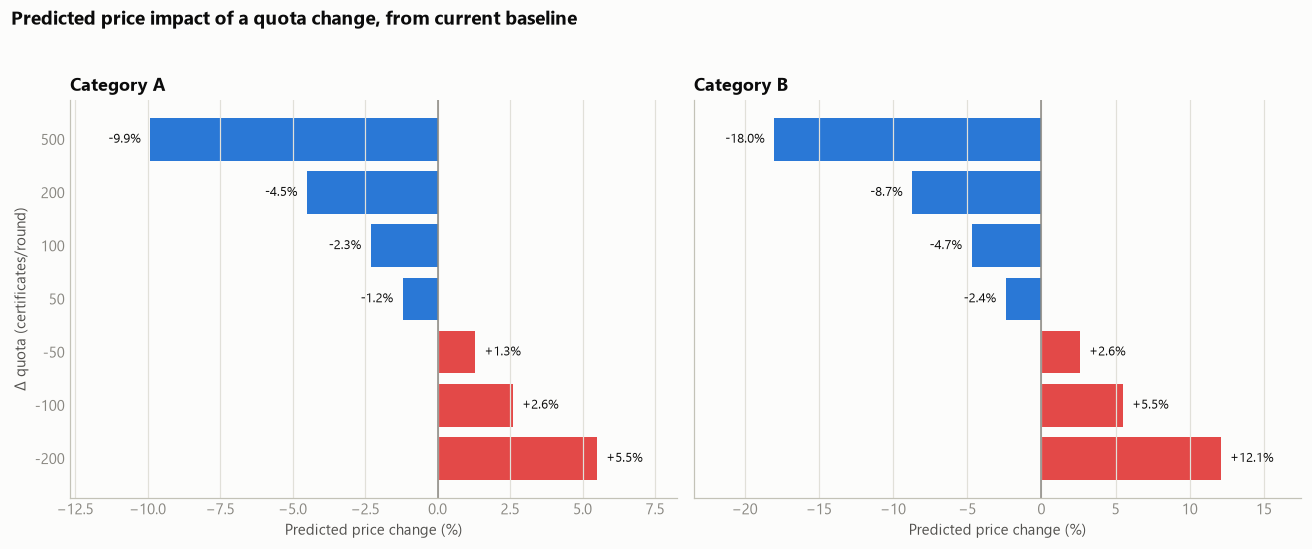

In [236]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), sharey=True)
for ax, cat in zip(axes, FOCUS_CATS):
    df = sim_tables[cat][sim_tables[cat]["Δ quota"] != 0]
    colors_bar = [DIVERGE_DOWN if v < 0 else DIVERGE_UP for v in df["% price change"]]
    bars = ax.barh([str(d) for d in df["Δ quota"]], df["% price change"], color=colors_bar)
    ax.axvline(0, color=INK_MUTED, linewidth=1)
    ax.set_title(cat, loc="left")
    ax.set_xlabel("Predicted price change (%)")
    if cat == "Category A":
        ax.set_ylabel("Δ quota (certificates/round)")
    style_ax(ax, ygrid_only=False)
    ax.grid(axis="x", visible=True, color=GRID)
    ax.grid(axis="y", visible=False)
    ax.margins(x=0.18)  # headroom so the outermost bar's label never overflows the axes
    for b, v in zip(bars, df["% price change"]):
        ax.annotate(f"{v:+.1f}%", (v, b.get_y() + b.get_height()/2), xytext=(6 if v >= 0 else -6, 0),
                     textcoords="offset points", va="center", ha="left" if v >= 0 else "right", fontsize=8.5)
fig.suptitle("Predicted price impact of a quota change, from current baseline", x=0.01, ha="left",
             fontsize=12.5, fontweight="bold", y=1.03)
fig.tight_layout()
fig.savefig(OUT_CHARTS / "14_quota_change_simulation.png", bbox_inches="tight")
plt.show()


example: Cat B, **+100 certificates/round → ~4.7% cooler price (~\$5,900)**. a 10% cut needs
~+235 certificates. big sustained move, not a small gesture. one number to remember tbh.

### 8.2 cross-check against the ml model


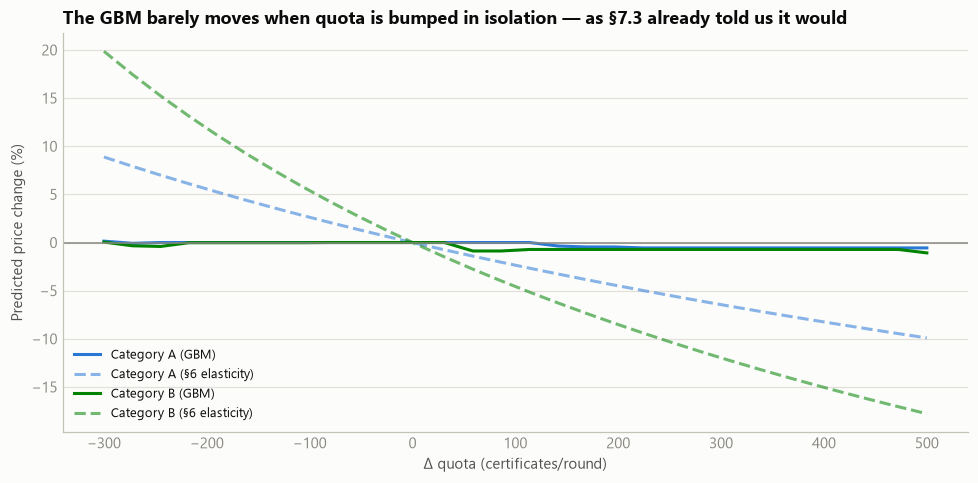

In [237]:
gbm_full = GradientBoostingRegressor(n_estimators=300, max_depth=3, learning_rate=0.05, subsample=0.8, random_state=42)
gbm_full.fit(ml_df[FEATURES], ml_df["ln_premium"])

fig, ax = plt.subplots(figsize=(9, 4.5))
for cat in FOCUS_CATS:
    base_row = ml_df[ml_df.vehicle_class == cat].sort_values("round_idx").tail(1)
    q0 = float(base_row["quota"].iloc[0])
    deltas_fine = np.linspace(-300, 500, 30)
    preds = []
    for d in deltas_fine:
        row = base_row.copy()
        row["quota"] = q0 + d
        row["ln_quota"] = np.log(row["quota"])
        preds.append(float(np.exp(gbm_full.predict(row[FEATURES]))[0]))
    p0 = preds[np.argmin(np.abs(deltas_fine))]
    ax.plot(deltas_fine, (np.array(preds) / p0 - 1) * 100, color=CAT_COLOR[cat], linewidth=2, label=f"{cat} (GBM)")
    elast_line = (1 + deltas_fine / q0) ** ELASTICITY[cat] - 1
    ax.plot(deltas_fine, elast_line * 100, color=CAT_COLOR[cat], linewidth=2, linestyle="--", alpha=0.55, label=f"{cat} (§6 elasticity)")
ax.axhline(0, color=INK_MUTED, linewidth=1)
ax.set_xlabel("Δ quota (certificates/round)")
ax.set_ylabel("Predicted price change (%)")
ax.set_title("The GBM barely moves when quota is bumped in isolation — as §7.3 already told us it would", loc="left")
style_ax(ax)
ax.legend(loc="lower left", frameon=False, fontsize=8.5)
fig.tight_layout()
fig.savefig(OUT_CHARTS / "15_gbm_vs_elasticity_crosscheck.png", bbox_inches="tight")
plt.show()


GBM's lines almost flat next to the elasticity model's, matches §7.3 (quota's only 0.4% of its
importance). not a "truer" answer, just a diff job. GBM predicts next round price, our model
answers "what if quota changes".

### 8.3 reality check: what actually happened

may 2023, LTA raised A/B quota (+24%/+15%). actual outcome vs §6's prediction:


In [238]:
event_rows = []
for cat in FOCUS_CATS:
    sub = master[master.vehicle_class == cat]
    before = sub[sub.month == "2023-04"]
    after = sub[sub.month.isin(["2023-05", "2023-06", "2023-07"])]
    q_b, q_a = before["quota"].mean(), after["quota"].mean()
    p_b, p_a = before["premium"].mean(), after["premium"].mean()
    actual_pct = (p_a / p_b - 1) * 100
    model_pct = ((q_a / q_b) ** ELASTICITY[cat] - 1) * 100
    event_rows.append({
        "category": cat, "quota Apr-23": round(q_b), "quota May-Jul-23": round(q_a),
        "quota % chg": round((q_a/q_b-1)*100, 1),
        "premium Apr-23": round(p_b), "premium May-Jul-23": round(p_a),
        "actual price % chg": round(actual_pct, 1), "model-implied % chg": round(model_pct, 1),
        "bid_to_quota Apr-23": round(before["bid_to_quota"].mean(), 2),
        "bid_to_quota May-Jul-23": round(after["bid_to_quota"].mean(), 2),
    })
event_df = pd.DataFrame(event_rows).set_index("category")
event_df.to_csv(OUT_DATA / "may2023_event_study.csv")
event_df.T


category,Category A,Category B
quota Apr-23,511.00,430.00
quota May-Jul-23,568.00,455.00
quota % chg,11.10,5.90
premium Apr-23,"100,111.00","119,695.00"
premium May-Jul-23,"96,568.00","118,356.00"
actual price % chg,-3.50,-1.10
model-implied % chg,-3.20,-2.50
bid_to_quota Apr-23,1.47,1.30
bid_to_quota May-Jul-23,1.38,1.38


**Cat A: excellent match** — model -3.2%, actual -3.5%. **Cat B: right direction, smaller** — model
-2.5%, actual -1.1%. why: B's `bid_to_quota` rose (1.30 → 1.38) over the same window, demand got
hotter just as supply loosened, canceled out some relief. reminder the model assumes only quota
changes. treat it as one input to a decision, not an auto answer.


## 9. Limitations

- quota's announced ahead of time but this still isnt a randomised experiment. the formula behind
  it is tied to the wider economy which also drives demand
- only one real event to check against (may-2023)
- one fixed elasticity across 16 yrs — buyer sensitivity mightve shifted since
- no data on the wider economy, OMV/ARF, or substitution to other categories/transport
- only one forecast test window (Sec 7)

**with more time:** bring in economic data, test more forecast windows, check if elasticity
shifted over time, turn Sec 8 into a live tool.
